In [15]:
import snapatac2 as snap    
import nbformat as nbf
import umap
import scvi
import numpy as np
import scanpy as sc
import anndata as ad

In [20]:
data = snap.pp.import_fragments(
    "/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/raw/241121-PBMC_results_masked/mgatk_output/final/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
data          

AnnData object with n_obs × n_vars = 24325 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [5]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''

#Idk why this isn't wokring something to do with chrome wtf

snap.pl.frag_size_distr(data, interactive=False)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [6]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [21]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

In [22]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=True)
data
##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/snapatac2/plotting/__init__.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = adata.obs["n_fragment"][selected_cells]
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/snapatac2/plotting/__init__.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = adata.obs["tsse"][selected_cells]
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or 

AnnData object with n_obs × n_vars = 24325 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [23]:
## OprionL - Filtering cells here results in fewer mitochondrial variants deteced
snap.pp.filter_cells(data, min_counts=1000, min_tsse=10, max_counts=100000)
data

/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning:

Transforming to str index.

/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning:

Transforming to str index.



AnnData object with n_obs × n_vars = 8110 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [24]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [25]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=250000)

2026-05-09 14:42:45 - INFO - Selected 250000 features.


In [26]:

## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(data, features=data.var['selected'].values)
#snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2026-05-09 14:42:47 - INFO - Simulating doublets...
2026-05-09 14:42:48 - INFO - Spectral embedding ...
2026-05-09 14:47:36 - INFO - Calculating doublet scores...
2026-05-09 14:47:43 - INFO - Detected doublet rate = 5.943%


AnnData object with n_obs × n_vars = 7628 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [27]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(data)
snap.tl.umap(data)

/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [28]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.7)  # Adjust resolution for more or fewer clusters

In [29]:
snap.pl.umap(data, color='leiden', interactive=True, height=500)

In [30]:
data.write_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_blood/anndata_PBMC_PM.h5ad")

... storing 'leiden' as categorical


In [20]:
#ELLIOT - lucas' Clustering done annotation begins 
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(
    data, 
    gene_anno=snap.genome.hg38,
    gene_name_key='gene_id'  # Use Ensembl IDs instead of gene symbols
)

# Remove version numbers from Ensembl IDs
gene_matrix.var_names = gene_matrix.var_names.str.replace(r'\.\d+$', '', regex=True)


In [21]:
#ELLIOT - Lucas' annotation method 
#import RNA reference data
reference = snap.read(snap.datasets.pbmc10k_multiome(),backed=None)
reference


# Check the cell type column name in your reference
print(reference.obs.columns)  # Find which column has cell types


Index(['domain', 'cell_type'], dtype='object')


In [14]:
# Check if datasets will merge properly
print(f"Gene matrix shape: {gene_matrix.shape}")
print(f"Reference shape: {reference.shape}")
print(f"\nGene matrix genes (first 10): {gene_matrix.var_names[:10].tolist()}")
print(f"Reference genes (first 10): {reference.var['gene_ids'].values[:10].tolist()}")

# Check overlap
ref_genes = set(reference.var['gene_ids'].values)
query_genes = set(gene_matrix.var_names)
overlap = ref_genes.intersection(query_genes)
print(f"\nShared genes: {len(overlap)}")
print(f"Reference only: {len(ref_genes - query_genes)}")
print(f"Gene matrix only: {len(query_genes - ref_genes)}")

Gene matrix shape: (7628, 61806)
Reference shape: (9631, 29095)

Gene matrix genes (first 10): ['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267', 'ENSG00000243485', 'ENSG00000284332', 'ENSG00000237613', 'ENSG00000268020', 'ENSG00000240361', 'ENSG00000186092', 'ENSG00000238009']
Reference genes (first 10): ['ENSG00000238009', 'ENSG00000241860', 'ENSG00000241599', 'ENSG00000286448', 'ENSG00000229905', 'ENSG00000237491', 'ENSG00000177757', 'ENSG00000228794', 'ENSG00000225880', 'ENSG00000230368']

Shared genes: 29000
Reference only: 95
Gene matrix only: 32806


In [22]:
#ELLIOT - Merge reference data and query data

# CRITICAL: Convert reference to use Ensembl IDs
reference.var_names = reference.var['gene_ids'].values
reference.var_names_make_unique()

# Now merge
gene_matrix.obs['cell_type'] = 'Unknown'
integrated = ad.concat(  # ← Fixed typo: intergrated → integrated
    [reference, gene_matrix],
    join='inner',
    label='batch',
    keys=["reference", "query"],
    index_unique='_',
)

print(f"Combined shape: {integrated.shape}")

Combined shape: (17259, 29000)


In [23]:
# scanpy finds highly variable genes (batch correction)
#if you ask callum he will say this is shit because this is porabbly just to make it faster
sc.pp.filter_genes(integrated, min_cells=5)
#find hvg
sc.pp.highly_variable_genes(
    integrated,
    n_top_genes = 5000,
    flavor="seurat_v3",
    batch_key="batch",
    subset=True
)

In [24]:
print(f"After HVG selection: {integrated.shape}")


After HVG selection: (17259, 5000)


In [26]:
#set up machine learning 
scvi.model.SCVI.setup_anndata(integrated, batch_key="batch")
vae = scvi.model.SCVI(
    integrated,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb",
    dispersion="gene-batch",
)

In [27]:
#pretraining model?
vae.train(max_epochs=100, early_stopping=True)


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

INFO: GPU available: False, used: False
2026-03-04 15:04:15 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2026-03-04 15:04:15 - INFO - TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

/home/elliot/miniconda3/en

Epoch 100/100: 100%|██████████| 100/100 [09:28<00:00,  3.35s/it, v_num=1, train_loss_step=1.45e+3, train_loss_epoch=1.67e+3]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
2026-03-04 15:13:44 - INFO - `Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [09:28<00:00,  5.69s/it, v_num=1, train_loss_step=1.45e+3, train_loss_epoch=1.67e+3]


<Axes: xlabel='epoch'>

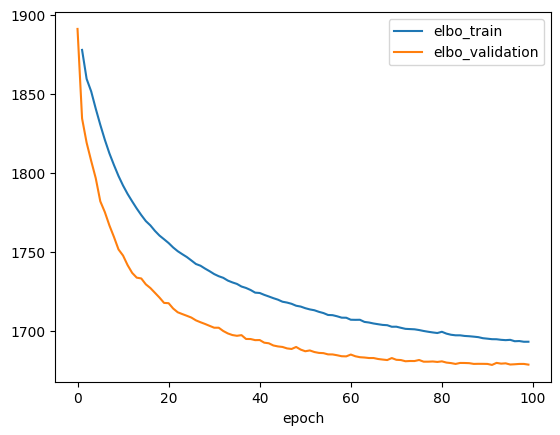

In [28]:
#plot training model to make sure it has converged 
ax = vae.history['elbo_train'][1:].plot()
vae.history['elbo_validation'].plot(ax=ax)


In [29]:
#setting up training model, check the 'class' or quivalent column is presetn in the refernce an merged object 
integrated.obs["celltype_scanvi"] = 'Unknown'
ref_idx = integrated.obs['batch'] == "reference"
integrated.obs.loc[ref_idx, "celltype_scanvi"] = integrated.obs.loc[ref_idx, 'cell_type'].astype(str) 


In [30]:
#who knows what this does maybe callum 
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=integrated,
    labels_key="celltype_scanvi",
    unlabeled_category="Unknown",
)

In [31]:
lvae.train(max_epochs=100, n_samples_per_label=100, early_stopping=True)

INFO     Training for 100 epochs.                                                                                  


/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

INFO: GPU available: False, used: False
2026-03-04 15:14:41 - INFO - GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
2026-03-04 15:14:41 - INFO - TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/atac_env/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning:

The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/atac_env/lib/python3.9/ ...

/home/elliot/miniconda3/en

Epoch 46/100:  46%|████▌     | 46/100 [08:17<09:43, 10.81s/it, v_num=1, train_loss_step=1.95e+3, train_loss_epoch=1.66e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1673.286. Signaling Trainer to stop.


<Axes: xlabel='epoch'>

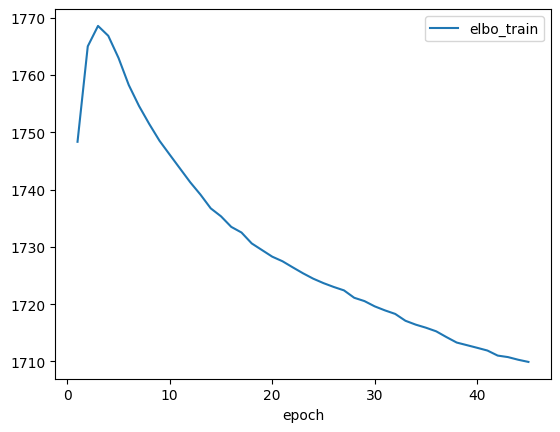

In [32]:
#plotting history as normal (if not saved)
lvae.history['elbo_train'][1:].plot()


In [33]:
# Now you can use the model
integrated.obs["C_scANVI"] = lvae.predict()
integrated.obsm["X_scANVI"] = lvae.get_latent_representation()

In [34]:
#generating uMAP
sc.pp.neighbors(integrated, use_rep="X_scANVI")
sc.tl.umap(integrated)

... storing 'cell_type' as categorical
... storing 'celltype_scanvi' as categorical
... storing 'C_scANVI' as categorical


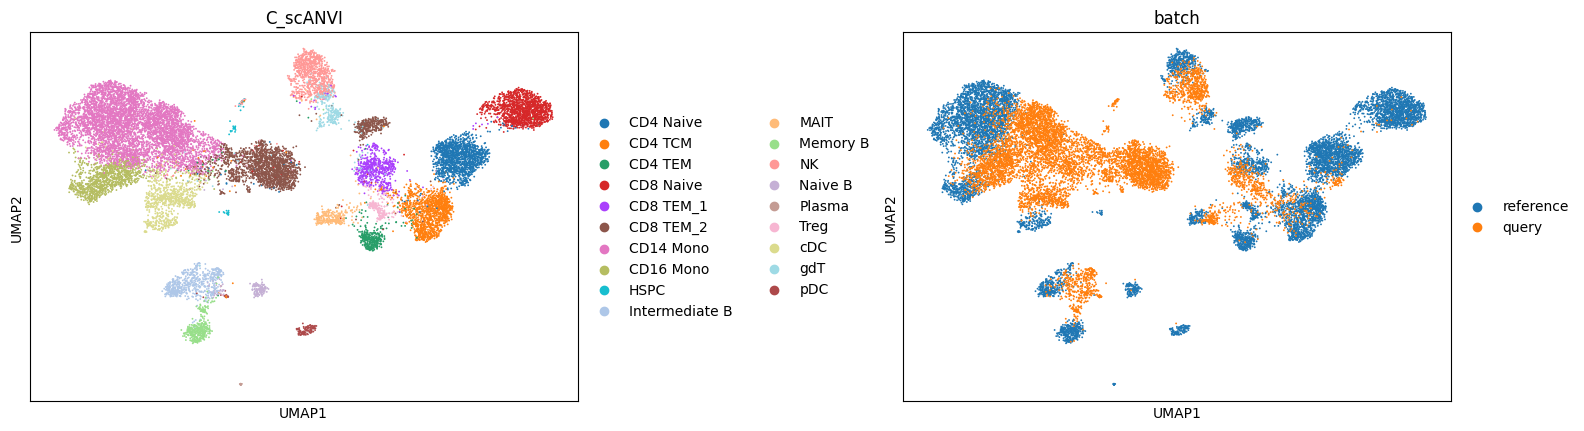

In [35]:
#Plotting uMAP querey and reference
sc.pl.umap(integrated, color=['C_scANVI', "batch"], wspace=0.45)


In [36]:
# Transfer predicted cell types back to original SnapATAC2 object
data.obs['cell_type'] = integrated.obs.loc[data.obs_names + '_query', 'C_scANVI'].to_numpy()

... storing 'leiden' as categorical
... storing 'cell_type' as categorical


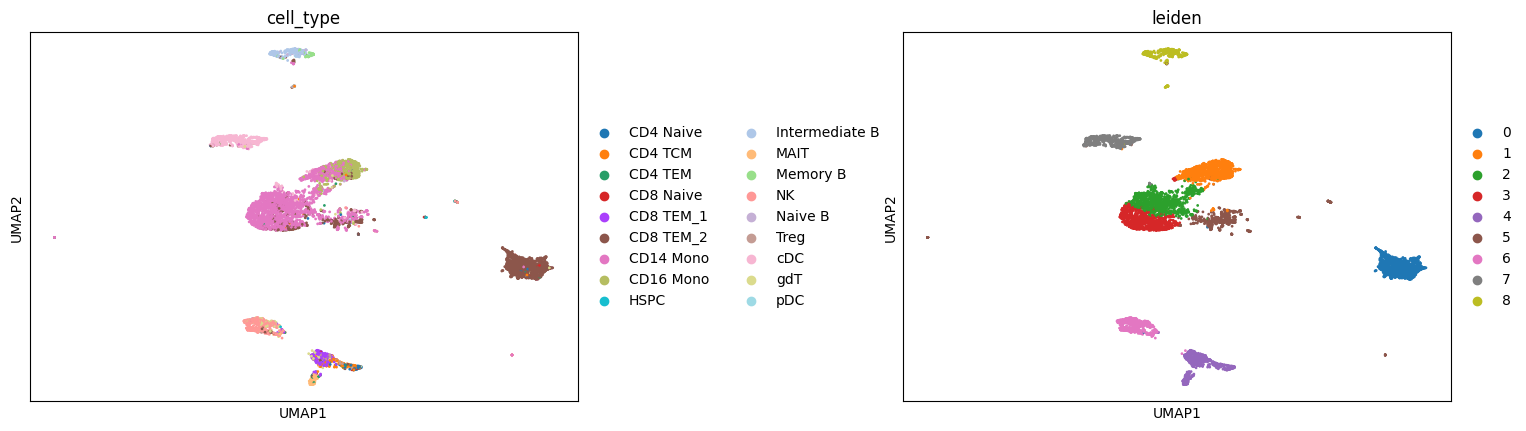

In [37]:
sc.pl.umap(data  , color=['cell_type', "leiden"], wspace=0.45)


In [39]:
broad_labels = {
    'CD4 Naive':      'CD4 T cells',
    'CD4 TCM':        'CD4 T cells',
    'CD4 TEM':        'CD4 T cells',
    'Treg':           'CD4 T cells',
    'CD8 Naive':      'CD8 T cells',
    'CD8 TEM_1':      'CD8 T cells',
    'CD8 TEM_2':      'CD8 T cells',
    'CD14 Mono':      'CD14 Monos',
    'CD16 Mono':      'CD16 Monos',
    'NK':             'NK cells',
    'Naive B':        'B cells',
    'Memory B':       'B cells',
    'Intermediate B': 'B cells',
    'cDC':            'DCs',
    'pDC':            'DCs',
    'HSPC':           'Unknown',
    'MAIT':           'Unknown',
    'gdT':            'Unknown',
    'Plasma':         'Unknown',
}

data.obs['cell_type_broad'] = data.obs['cell_type'].map(broad_labels).fillna('Unknown')
print(data.obs['cell_type_broad'].value_counts())


cell_type_broad
CD14 Monos     2616
CD8 T cells    2114
DCs             673
CD16 Monos      597
NK cells        459
CD4 T cells     417
B cells         408
Unknown         344
Name: count, dtype: int64


In [32]:
#save annotated object
data.write("annotated_PM_blood.h5ad")

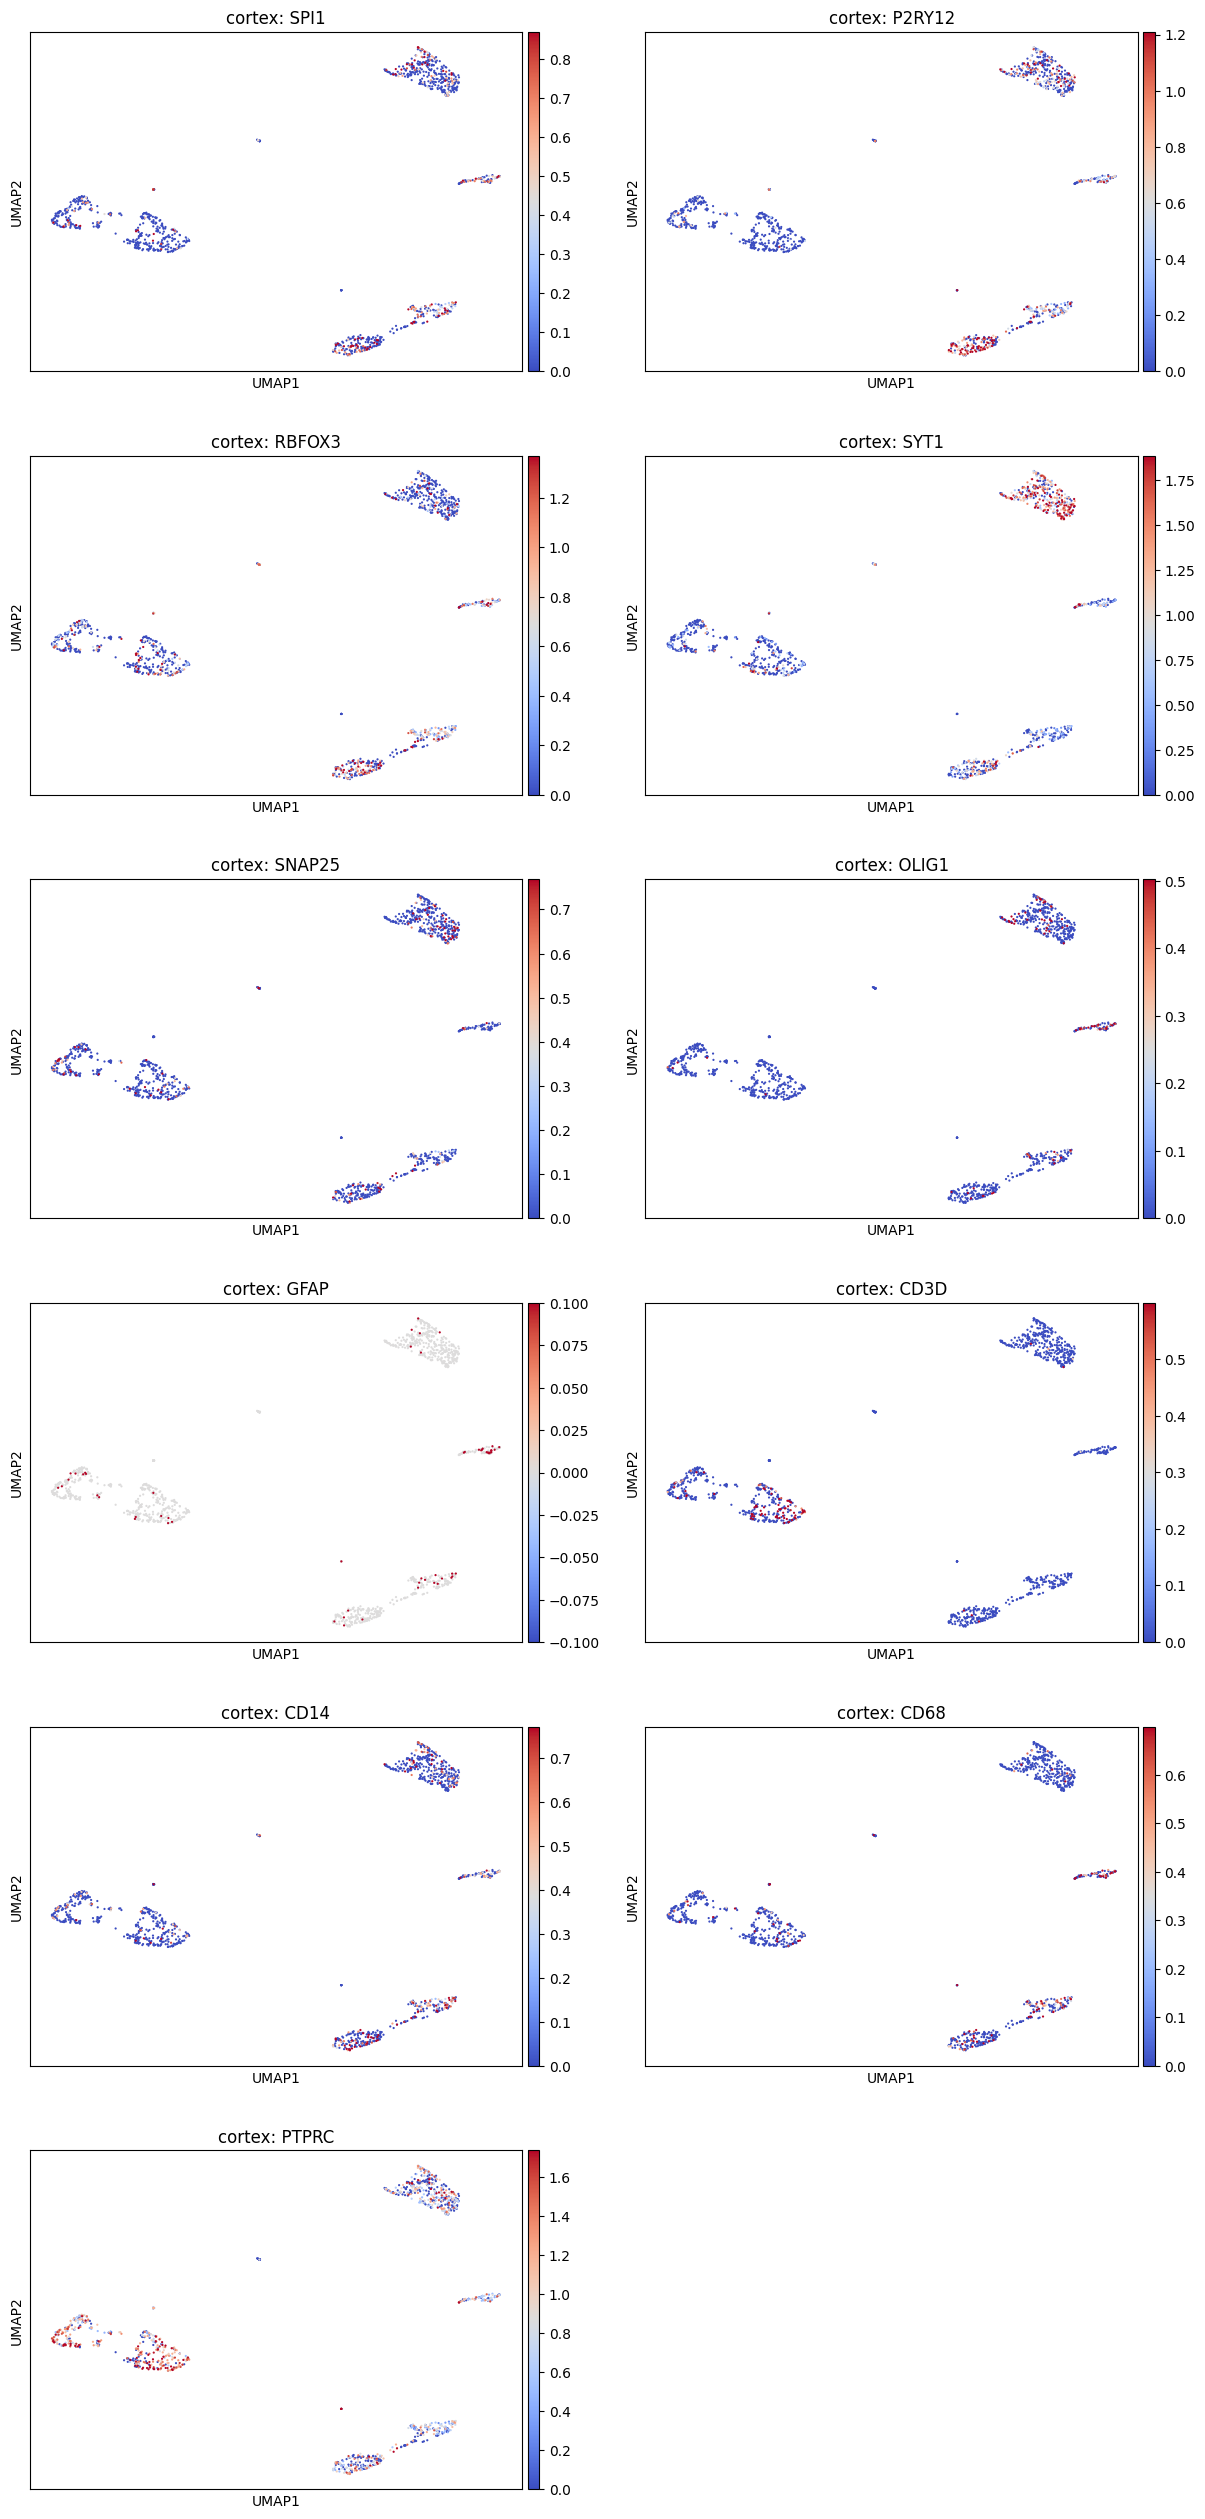

In [ ]:
import matplotlib.pyplot as plt

# Define marker genes for each cell type
celltype_markers = {
    #'PBMCs': ["CD4","CD8A","CD3D","NCAM1","FCGR3A","CD14","CD1C","CLEC9A","IL3RA","GZMB","C5AR1","CD34","CD19","MS4A1"], ## PTPRC is CD45, sample should be 70/30 CD4+/CD4-
    'cortex': ["SPI1","P2RY12","RBFOX3","SYT1","SNAP25","OLIG1","GFAP","CD3D","CD14","CD68","PTPRC"],
  
}

# Plot UMAPs for each cell type's marker genes
for celltype, genes in celltype_markers.items():
    sc.pl.umap(
        gene_matrix, 
        color=genes, 
        ncols=2, 
        cmap='coolwarm',
        vmax='p95',
        size=10,
        title=[f"{celltype}: {gene}" for gene in genes],
        show=True
    )
plt.show()


In [ ]:
#Elliot - mkaing a DEGs list actually, gene_matrix is an object NOT an acutal matrix 

# Get the number of top genes (should be 20 based on your plot)
n_genes = len(gene_matrix.uns['rank_genes_groups']['names'])

# Create a dictionary with DEG lists for each cluster
deg_lists = {}
for i in range(n_genes):
    for j, cluster in enumerate(gene_matrix.uns['rank_genes_groups']['names'].dtype.names):
        if cluster not in deg_lists:
            deg_lists[cluster] = []
        deg_lists[cluster].append(gene_matrix.uns['rank_genes_groups']['names'][i][j])

# Now deg_lists contains clean lists of top DEGs for each cluster
for cluster, genes in deg_lists.items():
    print(f"Cluster {cluster}: {genes[:20]}...")  # Show first 5 genes

Cluster 0: ['LRP1B', 'GRID2', 'ENSG00000231918', 'CNTN5', 'CNTNAP2', 'DPP10', 'ENSG00000251574', 'EYS', 'ROBO2', 'ERBB4', 'DMD', 'NAALADL2', 'CSMD3', 'ENSG00000254394', 'CDH18', 'RBMS3', 'ROBO1', 'ENSG00000248752', 'SPAG16', 'CADM2']...
Cluster 1: ['PELATON', 'CDH23', 'ENSG00000285565', 'RAD51B', 'PSAP', 'DAPK1', 'SLC24A4', 'PGS1', 'ENSG00000234261', 'PFKFB3', 'ZMIZ1', 'ENSG00000273112', 'HSPD1', 'MGAT1', 'BAG3', 'MBP', 'HSPH1', 'ENSG00000285016', 'DNAJB6', 'XYLT1']...
Cluster 2: ['ENSG00000234261', 'LINC00877', 'SCIRT', 'ENSG00000258137', 'HK2', 'JARID2', 'ZMIZ1', 'ENSG00000258086', 'CUX1', 'PRKAG2', 'RBM47', 'RIN2', 'SLCO3A1', 'GAS7', 'RFX2', 'NCOR2', 'TIMP2', 'ENSG00000289728', 'DMXL2', 'FNDC3B']...
Cluster 3: ['HK2', 'CUX1', 'FNDC3B', 'RUNX1', 'PRKAG2', 'MAML3', 'JARID2', 'ASAP1', 'ENSG00000289728', 'DOCK5', 'ENSG00000259345', 'SLCO3A1', 'RPTOR', 'SLC24A4', 'ENSG00000286022', 'IGF2BP2', 'DOCK2', 'PPARG', 'LUCAT1', 'NIBAN2']...
Cluster 4: ['BCL11B', 'RORA', 'RORA-AS1', 'SCML4', 'ITK

... storing 'leiden' as categorical


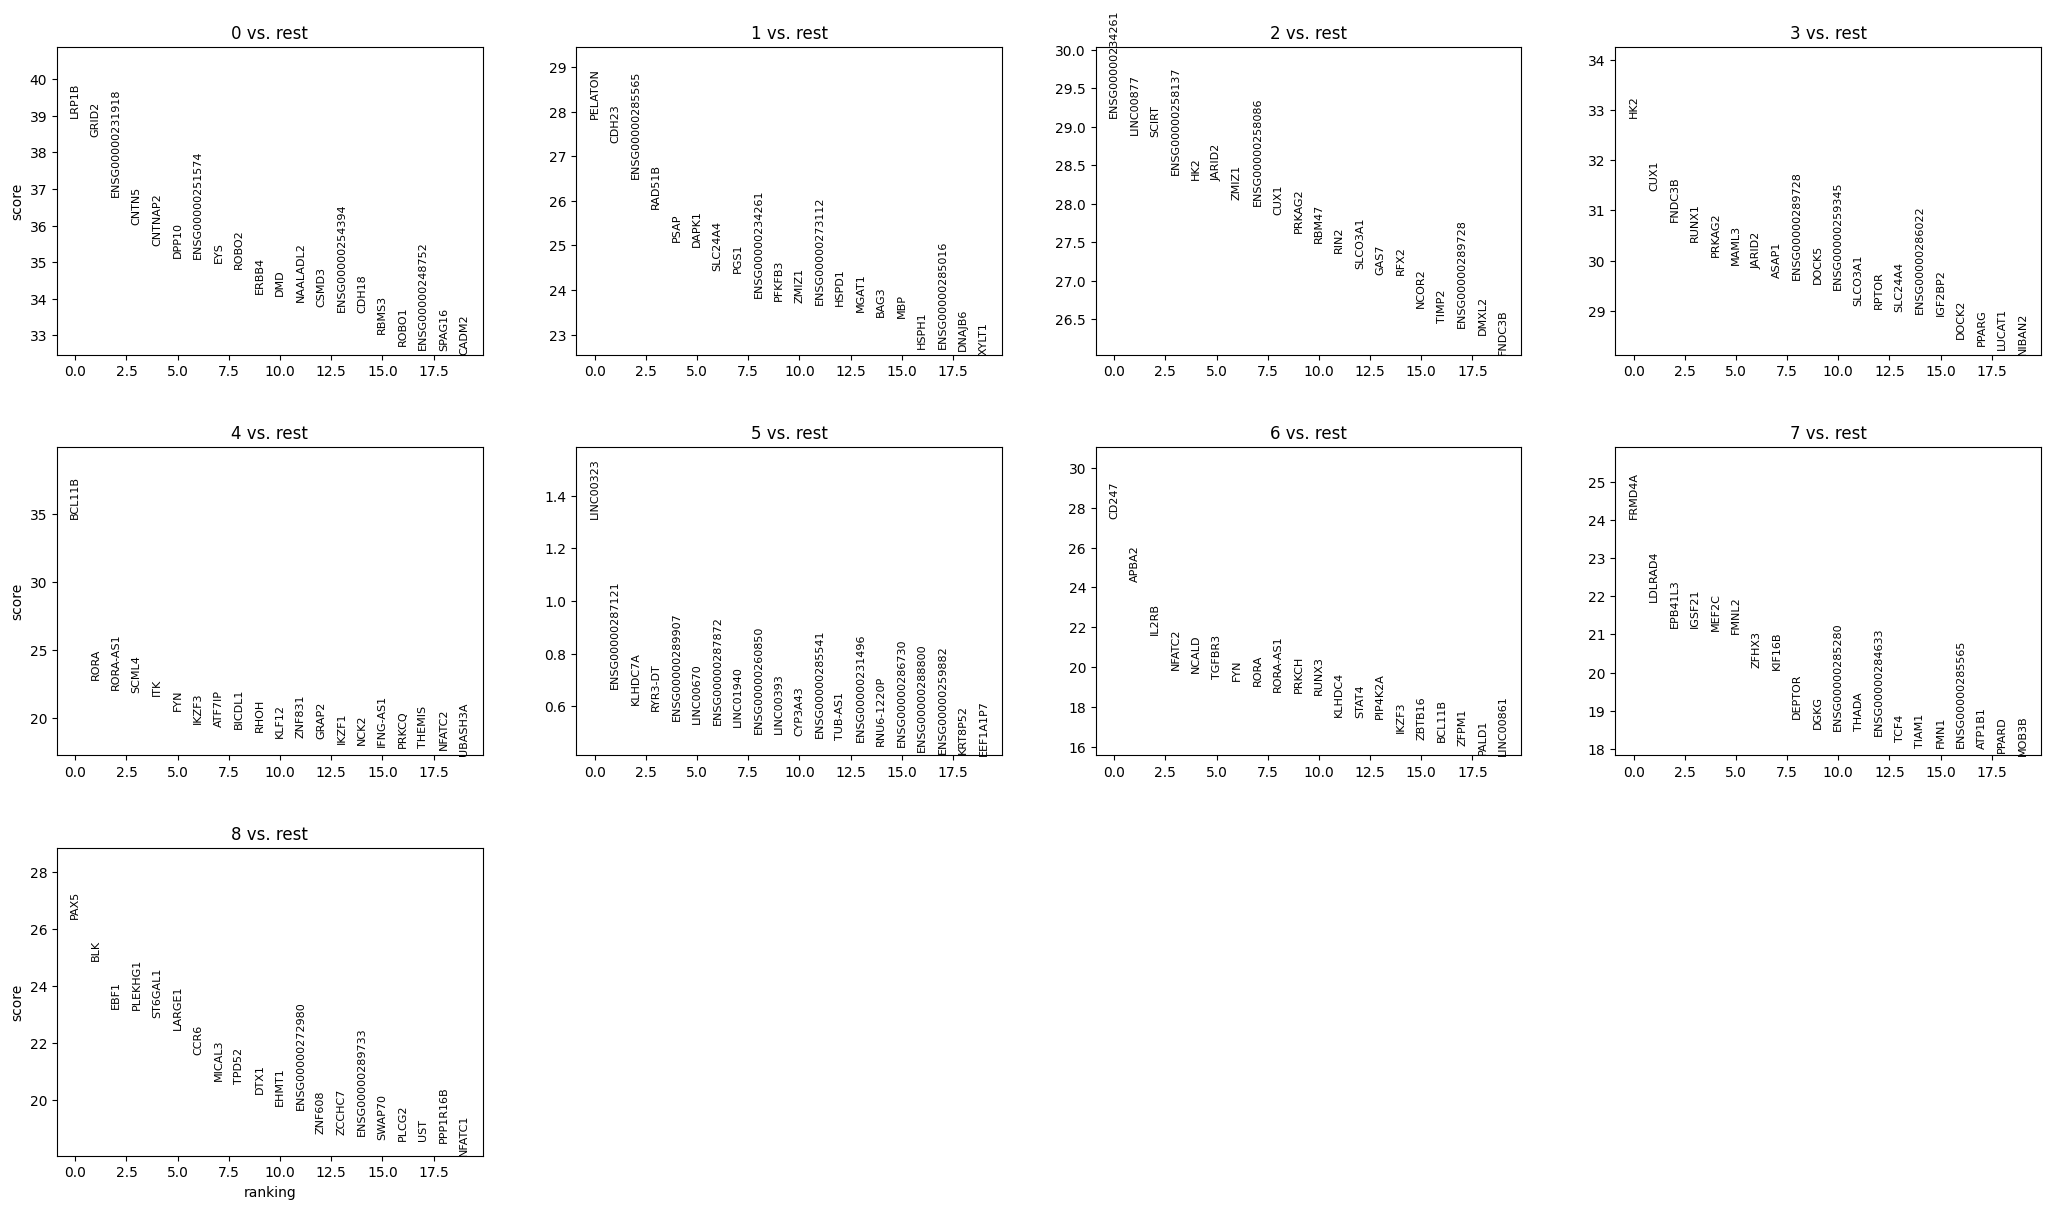

In [ ]:
# Run differential expression analysis between clusters (e.g., 'leiden' clusters)
sc.tl.rank_genes_groups(gene_matrix, groupby='leiden', method='wilcoxon')

# Show the top marker genes for each cluster
sc.pl.rank_genes_groups(gene_matrix, n_genes=20, sharey=False)



In [ ]:
##Not clear what the clusters are so I am going to do vague annotations
##Annotatig 
cluster_to_celltype = {
    "6": "CD4 T cell",
    "0": "Macrophage",
    "3": "CD8 T cell",
    "1": "NK cell",
    "2": "Monocytes",
    "4": "Unsure",
    "5": "Unsure",
    "7": "B cell"
   
    # Add more as needed
}

... storing 'celltype' as categorical


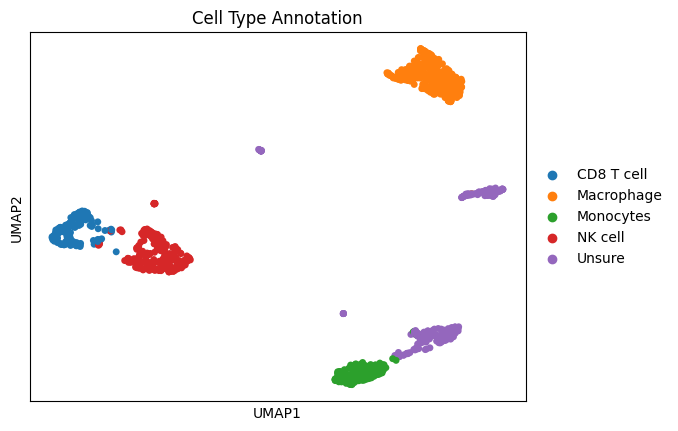

In [ ]:
gene_matrix.obs['celltype'] = gene_matrix.obs['leiden'].map(cluster_to_celltype)
sc.pl.umap(gene_matrix, color=['celltype'], title="Cell Type Annotation")

In [ ]:
# !!!!!!!!!!!!!!!!!! !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!OK SO NOW THE MT VARIANT CALLING BEGINS STOP HERE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [31]:
import sys
sys.path.insert(0, '/mnt/claw-raid/elliot/P002_mtscATAC-seq/scripts/Py_mTCall_tools/Py_mTCall_tools')
import variant_calling_fast as vc

mgatk = vc.process_variants_fast(
    "/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/raw/241121-PBMC_results_masked/mgatk_output/final",
    data,
    verbose=True,
    coverage_threshold=10
)
data

=== Fast Variant Calling Pipeline ===


You'll find variant names in adata.uns['variant_names']

Find coverage PER cell in adata.obsm['coverage_per_cell']

Variant summmary stats similar to Signac are in adata.uns['variant_summary']

Variant matrices are in adata.obsm["variant_vaf"]


=== IMPORTANT NOTE ===

Remember that variant VAFs are only included if they pass the min_strand_count filter

AND the coverage threshold if specified!



Loaded counts data: (132095, 8368)
Loaded coverage data: (131841933, 3)
Identifying variants (memory-optimized chunked method)...
Processing all 98891 variant observations (no artificial limits)
Integrating with AnnData...
=== Pipeline Complete ===
Processed 4701 variants in 6877 matching cells


AnnData object with n_obs × n_vars = 7628 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'total_variant_count'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate', 'spectral_eigenvalue', 'variant_summary', 'variant_names'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap', 'variant_vaf', 'variant_counts', 'coverage_per_cell', 'variant_confident'
    obsp: 'distances'

In [35]:
import pandas as pd

vaf_matrix = mgatk.obsm['variant_vaf']
cell_names = mgatk.obs.index
variant_names = pd.Index(mgatk.uns['variant_names'])



# Leiden cell filter
leiden_clusters_to_keep = [ '3', '2', '1']
keep_cells_mask = mgatk.obs['leiden'].isin(leiden_clusters_to_keep)
keep_cells = mgatk.obs.index[keep_cells_mask]

print(f"Cells BEFORE leiden filter: {len(cell_names)}")
print(f"Cells AFTER leiden filter:  {len(keep_cells)}")

# Filter matrices to leiden cells
vaf_leiden = vaf_matrix[keep_cells_mask]
cov_leiden = mgatk.obsm['coverage_per_cell'][keep_cells_mask]

# *** FIXED: Combined mask - leiden signal AND high confidence ***
conf_stats = mgatk.uns['variant_summary']
high_conf_mask = conf_stats['n_cells_conf_detected'] >= 3

# Leiden-specific signal in high-conf vars only
leiden_signal_in_conf = (vaf_leiden[:, high_conf_mask] > 0).any(axis=0)
leiden_high_conf_vars = variant_names[high_conf_mask][leiden_signal_in_conf]

print(f"High-conf variants total:     {high_conf_mask.sum()}")
print(f"High-conf + leiden signal:   {len(leiden_high_conf_vars)}")

# Build matrices for leiden_cells × leiden_high_conf_vars
overall_coverage_df = pd.DataFrame(
    data=cov_leiden[:, high_conf_mask][:, leiden_signal_in_conf],
    index=keep_cells,
    columns=leiden_high_conf_vars
)
phylogeny_df = pd.DataFrame(
    data=vaf_leiden[:, high_conf_mask][:, leiden_signal_in_conf],
    index=keep_cells,
    columns=leiden_high_conf_vars
)

# --- Median depth filter per cell (on final variants) ---
coverage_final = overall_coverage_df.values
median_d_final = np.median(coverage_final, axis=1)   # median across final variants per cell
good_cells_mask = median_d_final >= 0 #across all final variants, cell must have median coverage of at least 10
keep_cells_final = overall_coverage_df.index[good_cells_mask]

print(f"Cells AFTER median_d >= 10 filter: {len(keep_cells_final)} / {len(keep_cells)}")

# --- Update matrices to only good cells (for MitoDrift / long‑format) ---
overall_coverage_df = overall_coverage_df.loc[keep_cells_final]
phylogeny_df = phylogeny_df.loc[keep_cells_final]

# Rest unchanged...
alt_counts_df = phylogeny_df.mul(overall_coverage_df, fill_value=0).round().astype(int)

alt_long = alt_counts_df.reset_index().melt(id_vars='index', var_name='variant', value_name='a')
cov_long = overall_coverage_df.reset_index().melt(id_vars='index', var_name='variant', value_name='d')
long_df = alt_long.copy()
long_df['d'] = cov_long['d'].round().astype(int)
long_df = long_df.rename(columns={'index': 'cell'})
long_df = long_df[['cell', 'variant', 'a', 'd']]

# Haplogroup filter
haplogroup_positions = ['73', '263', '750', '1438', '2706', '4769', '7028', '8860', 
                       '11719', '14766', '15326', '16519', '6776']
long_df_final = long_df[~long_df['variant'].str.contains('|'.join(haplogroup_positions))].reset_index(drop=True)

print(f"FINAL: {len(keep_cells_final)} cells × {len(long_df_final['variant'].unique())} variants")
long_df_final.to_csv("/mnt/claw-raid/elliot/P002_mtscATAC-seq/MitoDrift/MonoSubsets/PM_Monos_subset.csv", index=False)

Cells BEFORE leiden filter: 7628
Cells AFTER leiden filter:  3103
High-conf variants total:     643
High-conf + leiden signal:   506
Cells AFTER median_d >= 10 filter: 3103 / 3103
FINAL: 3103 cells × 475 variants


In [10]:
import numpy as np

cov_matrix = mgatk.obsm['variant_coverage']
print(f"Shape: {cov_matrix.shape} (cells x variants, matches vaf: {mgatk.obsm['variant_vaf'].shape})")
print(f"Sample values:\n{cov_matrix[:3, :5]}")  # First 3 cells, 5 variants
print(f"Mean coverage: {np.mean(cov_matrix):.1f}, Min: {np.min(cov_matrix)}")  # Expect >0 integers/floats
print(f"Total per cell example: {np.sum(cov_matrix[0])}")  # Matches obs['total_variant_count']?

Shape: (7628, 45841) (cells x variants, matches vaf: (7628, 45841))
Sample values:
[[29. 33. 41. 50. 50.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Mean coverage: 20.0, Min: 0.0
Total per cell example: 2206002.0


In [4]:
mgatk = ad.read_h5ad('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_blood/old/PM_blood_mgatk.h5ad')

In [43]:
import pickle
import numpy as np
import pandas as pd

# Load
brain_1pct = pickle.load(open('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/microglia_clonal_1pct_pairs.pkl', 'rb'))
brain_3pct = pickle.load(open('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/microglia_clonal_3pct_pairs.pkl', 'rb'))
brain_5pct = pickle.load(open('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/microglia_clonal_5pct_pairs.pkl', 'rb'))

total_blood = 7628

def make_table(brain_pairs, cutoff_pct):
    data = []
    cutoff_n = max(1, int(total_blood * cutoff_pct / 100))
    
    for var, type_pairs in sorted(brain_pairs.items()):
        i = np.where(mgatk.uns['variant_names'] == var)[0]
        if len(i) == 0: continue
        
        n_blood_total = int(mgatk.obsm['variant_confident'][:, i[0]].sum())
        n_blood_cutoff = n_blood_total if n_blood_total >= cutoff_n else 0
        
        # Get n_micro from FIRST pair (all pairs have same n_micro per var)
        n_microglia = type_pairs[0][1]
        
        # Types: "oligos, endos"
        absent_types = ', '.join([pair[0].split()[0] for pair in type_pairs])
        
        data.append([var, n_microglia, n_blood_cutoff, absent_types])
    
    df = pd.DataFrame(data, columns=['variant', 'n_microglia', f'n_blood_{cutoff_pct}%', 'absent_brain_celltype'])
    return df

print("1% Cutoff")
print(make_table(brain_1pct, 1))
print("\n" + "="*80 + "\n")

print("3% Cutoff")
print(make_table(brain_3pct, 3))
print("\n" + "="*80 + "\n")

print("5% Cutoff")
print(make_table(brain_5pct, 5))


1% Cutoff
      variant  n_microglia  n_blood_1%  \
0   A-11719-G          114        6530   
1   A-16255-G          101        6457   
2    A-1719-G          111        6489   
3     A-225-G           55        5556   
4     A-834-G            2           0   
5   C-14470-T          102        6371   
6   C-16183-A           34        4006   
7   C-16189-T           36        4484   
8   C-16519-T          100        6482   
9    C-1824-T          108        6402   
10    C-195-T           74        5911   
11    C-310-T            3        2077   
12   C-3107-N            3        1554   
13   C-3109-T            2        1392   
14   C-6221-T          110        6520   
15   C-8705-T          109        6505   
16  G-13966-A          115        6562   
17   G-1438-A          107        6518   
18    G-153-A           83        5987   
19  G-15326-A          117        6596   
20  G-16289-A            2         206   
21    G-227-A           56        5572   
22    G-263-A           

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/variants_by_celltype_full_brain.csv'

/tmp/ipykernel_3041494/1925951792.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=plot_df, x='cell_type', y='n_somatic_variants',
/tmp/ipykernel_3041494/1925951792.py:39: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=plot_df, x='cell_type', y='mean_het_vaf',


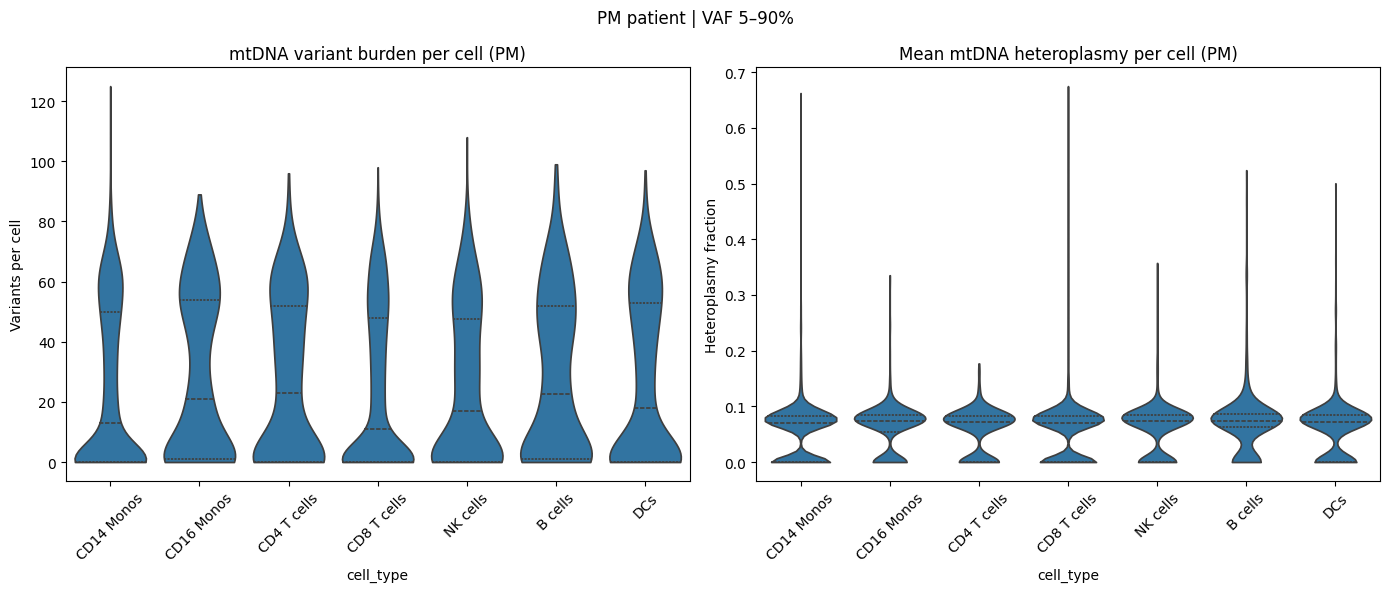

In [5]:
import sys
sys.path.insert(0, '/mnt/claw-raid/elliot/P002_mtscATAC-seq/scripts/Py_mTCall_tools/Py_mTCall_tools')
import variant_calling_fast as vc
import anndata as ad
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load PM mgatk object
mgatk = ad.read_h5ad('/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_blood/PM_blood_mgatk.h5ad')

# Recalculate somatic metrics (same as surgical)
thresh_low, thresh_high = 0.05, 0.9
vaf_matrix = mgatk.obsm['variant_vaf']
conf_matrix = mgatk.obsm['variant_confident']
het_mask = (vaf_matrix >= thresh_low) & (vaf_matrix < thresh_high) & conf_matrix

mgatk.obs['n_somatic_variants'] = np.array(het_mask.sum(axis=1)).flatten()

mean_het = []
for i in range(mgatk.n_obs):
    cell_mask = het_mask[i]
    vals = vaf_matrix[i][cell_mask]
    mean_het.append(np.mean(vals) if len(vals) > 0 else 0.0)
mgatk.obs['mean_het_vaf'] = mean_het

# Now plot
ct_keep = ['CD14 Monos', 'CD16 Monos', 'CD4 T cells', 'CD8 T cells', 'NK cells', 'B cells', 'DCs']
plot_df = mgatk.obs[mgatk.obs['cell_type'].isin(ct_keep)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=plot_df, x='cell_type', y='n_somatic_variants',
               order=ct_keep, inner='quartile', scale='width', cut=0, ax=axes[0])
axes[0].set_title('mtDNA variant burden per cell (PM)')
axes[0].set_ylabel('Variants per cell')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=plot_df, x='cell_type', y='mean_het_vaf',
               order=ct_keep, inner='quartile', scale='width', cut=0, ax=axes[1])
axes[1].set_title('Mean mtDNA heteroplasmy per cell (PM)')
axes[1].set_ylabel('Heteroplasmy fraction')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('PM patient | VAF 5–90%', fontsize=12, y=0.98)
plt.tight_layout()
plt.savefig('per_cell_PM.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
mgatk.obs[['n_somatic_variants', 'mean_het_vaf', 'cell_type']].to_csv(
    '/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_PM_blood/PM_cell_burden.csv'
)


In [39]:
#no of cells with 1 or more high quality vairant 
(mgatk.obs['total_confident_variants'] >= 1).sum()

6870

In [40]:
# Assuming 'mgatk' is your anndata object containing the coverage matrix
coverage_matrix = mgatk.obsm['variant_coverage']
# Calculate the mean coverage across all variants (axis=1) for each cell
mean_coverage = np.mean(coverage_matrix, axis=1)
# Count cells where the mean coverage is greater than 10
num_cells = np.sum(mean_coverage > 10)
# Print the result
print(f"Number of cells with mean coverage > 10: {num_cells}")



Number of cells with mean coverage > 10: 4867


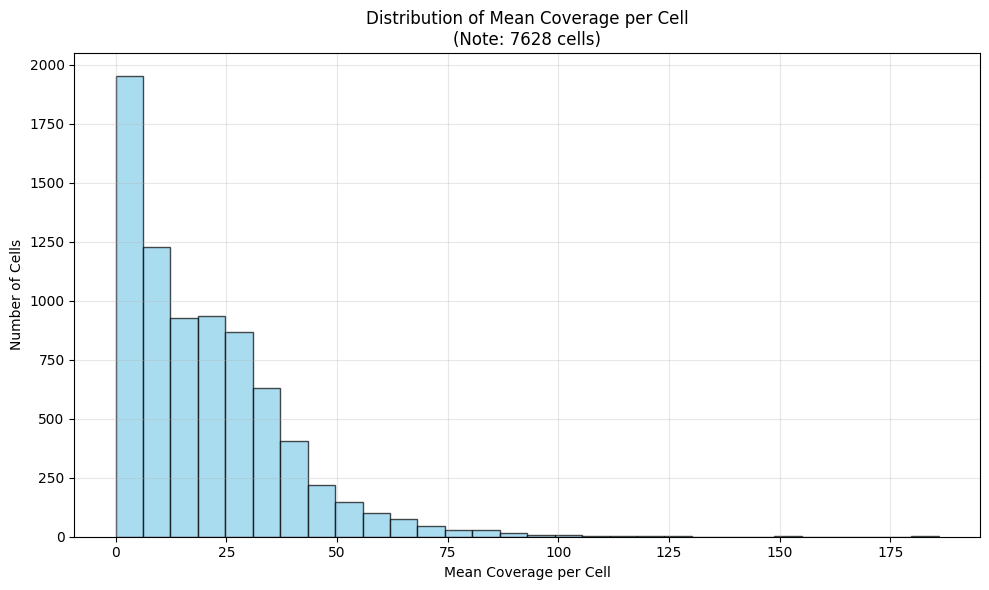

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get coverage data from the correct location
coverage_matrix = mgatk.obsm['variant_coverage']
mean_coverage_per_cell = np.mean(coverage_matrix, axis=1)

# Create the distribution plot
plt.figure(figsize=(10, 6))
plt.hist(mean_coverage_per_cell, bins=30, alpha=0.7, edgecolor='black', color='skyblue')

plt.xlabel('Mean Coverage per Cell')
plt.ylabel('Number of Cells')
plt.title(f'Distribution of Mean Coverage per Cell\n(Note: {len(mean_coverage_per_cell)} cells)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

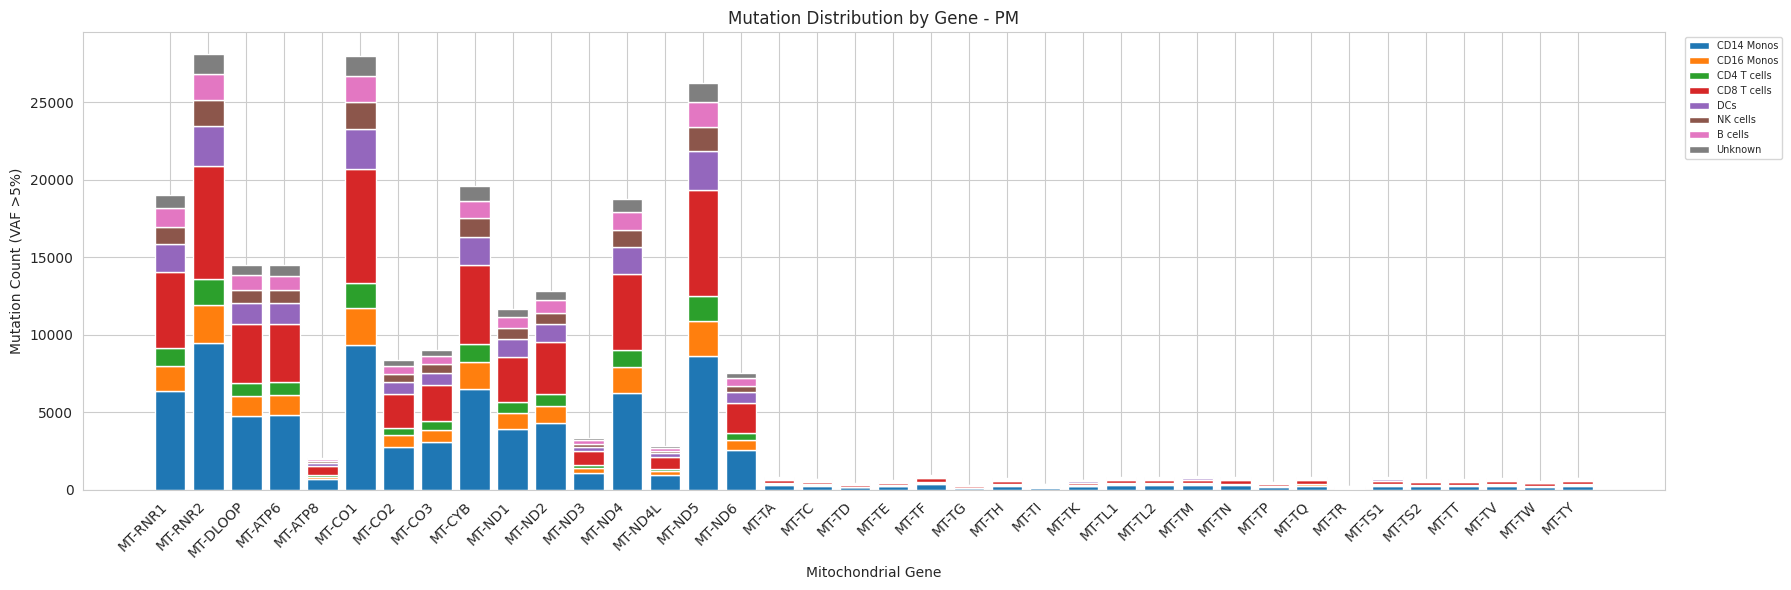

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.sparse import issparse

CT_COLOURS = {
    'CD14 Monos': '#1f77b4',
    'CD16 Monos': '#ff7f0e',
    'CD4 T cells': '#2ca02c',
    'CD8 T cells': '#d62728',
    'DCs':         '#9467bd',
    'NK cells':    '#8c564b',
    'B cells':     '#e377c2',
    'Unknown':     '#7f7f7f',
}

gene_coords = {
    'MT-RNR1':  (648,   1601), 'MT-RNR2':  (1671,  3229),
    'MT-DLOOP': (16024, 16569),'MT-ATP6':  (8527,  9207),
    'MT-ATP8':  (8366,  8572), 'MT-CO1':   (5904,  7445),
    'MT-CO2':   (7586,  8269), 'MT-CO3':   (9207,  9990),
    'MT-CYB':   (14747, 15887),'MT-ND1':   (3307,  4262),
    'MT-ND2':   (4470,  5511), 'MT-ND3':   (10059, 10404),
    'MT-ND4':   (10760, 12137),'MT-ND4L':  (10470, 10766),
    'MT-ND5':   (12337, 14148),'MT-ND6':   (14149, 14673),
    'MT-TA':    (5587,  5655), 'MT-TC':    (5761,  5826),
    'MT-TD':    (7518,  7585), 'MT-TE':    (14674, 14742),
    'MT-TF':    (577,   647),  'MT-TG':    (9991,  10058),
    'MT-TH':    (12138, 12206),'MT-TI':    (4263,  4331),
    'MT-TK':    (8295,  8364), 'MT-TL1':   (3230,  3304),
    'MT-TL2':   (12266, 12336),'MT-TM':    (4402,  4469),
    'MT-TN':    (5657,  5729), 'MT-TP':    (15956, 16023),
    'MT-TQ':    (4329,  4400), 'MT-TR':    (10405, 10469),
    'MT-TS1':   (7446,  7514), 'MT-TS2':   (12207, 12265),
    'MT-TT':    (15888, 15953),'MT-TV':    (1602,  1670),
    'MT-TW':    (5512,  5579), 'MT-TY':    (5826,  5891),
}

# FIXED: Use mgatk.obs['cell_type_broad'] directly (your h5ad has it)
mgatk.obs['cell_type'] = mgatk.obs['cell_type_broad'].astype(str).str.strip()
mgatk.obs['cell_type'] = mgatk.obs['cell_type'].replace('nan', 'Unknown')

variant_names = np.array(mgatk.uns['variant_names'])
positions = np.array([int(n.split('-')[1]) for n in variant_names])

cell_types = mgatk.obs['cell_type'].values
unique_ct = [ct for ct in CT_COLOURS if ct in mgatk.obs['cell_type'].unique()]

vaf_dense = mgatk.obsm['variant_vaf'].toarray() if issparse(mgatk.obsm['variant_vaf']) else np.array(mgatk.obsm['variant_vaf'])

gene_names = list(gene_coords.keys())
counts = pd.DataFrame(0, index=gene_names, columns=unique_ct)

for gene, (start, end) in gene_coords.items():
    gene_mask = (positions >= start) & (positions <= end)
    gene_vaf = vaf_dense[:, gene_mask]
    for ct in unique_ct:
        ct_mask = cell_types == ct
        counts.loc[gene, ct] = (gene_vaf[ct_mask] > 0.05).sum()

# SAVE data
counts.to_csv('/mnt/claw-raid/elliot/PM_gene_mutation_counts.csv')

# EXACT SAME VISUAL (your original style)
fig, ax = plt.subplots(figsize=(18, 6))
bottom = np.zeros(len(gene_names))
for ct in unique_ct:
    vals = counts[ct].values.astype(float)
    ax.bar(gene_names, vals, bottom=bottom, label=ct, color=CT_COLOURS[ct])
    bottom += vals

ax.set_xlabel("Mitochondrial Gene")
ax.set_ylabel("Mutation Count (VAF >5%)")
ax.set_title("Mutation Distribution by Gene - PM")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# PUBLICATION SAVE
plt.savefig('/mnt/claw-raid/elliot/PM_gene_mutation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_2987780/916731838.py:11: RuntimeWarning:

invalid value encountered in divide



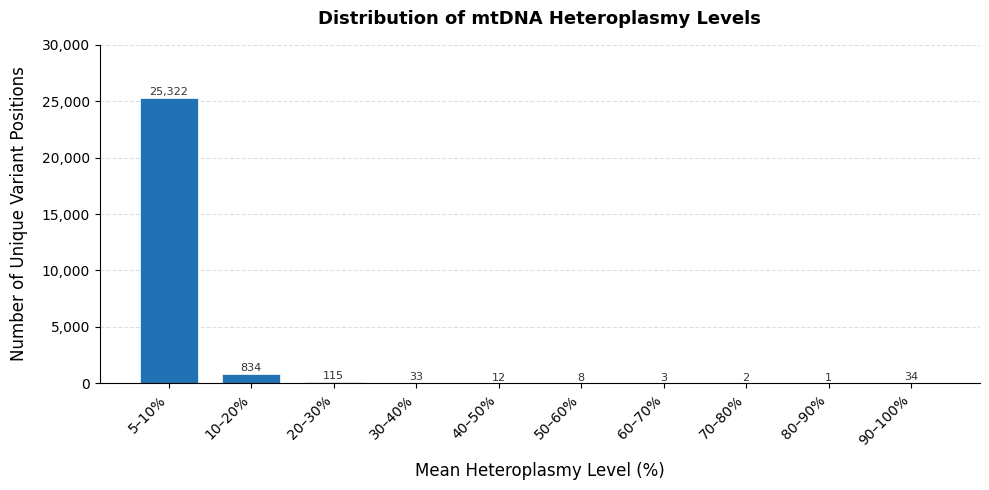

In [ ]:
#simple for ethan 
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import issparse

vaf = mgatk.obsm['variant_vaf']
vaf_dense = vaf.toarray() if issparse(vaf) else np.array(vaf)

cell_counts = (vaf_dense > 0).sum(axis=0)
mean_vaf_per_variant = np.where(
    cell_counts > 0,
    vaf_dense.sum(axis=0) / cell_counts,
    0
)
mean_vaf_per_variant = mean_vaf_per_variant[mean_vaf_per_variant >= 0.05]

bin_edges = np.array([0.05, 0.10, 0.20, 0.30, 0.40,
                      0.50, 0.60, 0.70, 0.80, 0.90, 1.00])
bin_labels = ['5–10%', '10–20%', '20–30%', '30–40%',
              '40–50%', '50–60%', '60–70%', '70–80%',
              '80–90%', '90–100%']

counts, _ = np.histogram(mean_vaf_per_variant, bins=bin_edges)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(x := np.arange(len(counts)), counts, width=0.7,
              color='#2171b5', edgecolor='white', linewidth=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontsize=8, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f'{int(y):,}' for y in ax.get_yticks()], fontsize=10)

ax.set_xlabel('Mean Heteroplasmy Level (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Unique Variant Positions', fontsize=12, labelpad=10)
ax.set_title('Distribution of mtDNA Heteroplasmy Levels', fontsize=13, fontweight='bold', pad=15)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2987780/2780301516.py:31: RuntimeWarning:

Mean of empty slice



Mann-Whitney U = 6368914,  p = 3.6491e-02
CD14 Monos median VAF = 0.134,  All Other Cells median VAF = 0.143


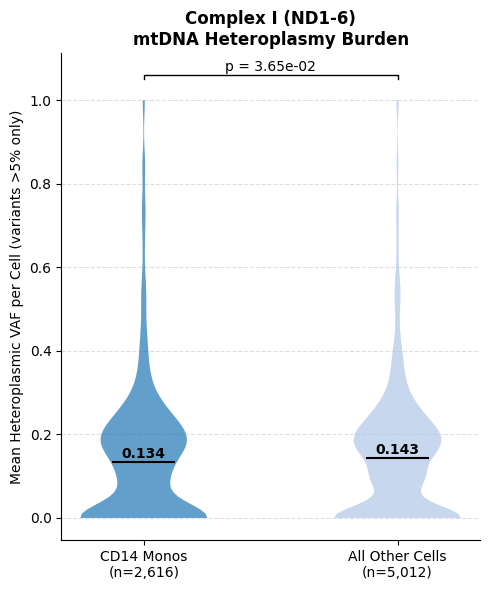

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import issparse
from scipy.stats import mannwhitneyu

# ── Extract VAF matrix ──────────────────────────────────────────────────────
vaf = mgatk.obsm['variant_vaf']
vaf_dense = vaf.toarray() if issparse(vaf) else np.array(vaf)

variant_names = np.array(mgatk.uns['variant_names'])
positions = np.array([int(n.split('-')[1]) for n in variant_names])
cell_types = mgatk.obs['cell_type'].values

gene_coords = {
    'MT-ND1':  (3307,  4262),
    'MT-ND2':  (4470,  5511),
    'MT-ND3':  (10059, 10404),
    'MT-ND4':  (10760, 12137),
    'MT-ND4L': (10470, 10766),
    'MT-ND5':  (12337, 14148),
    'MT-ND6':  (14149, 14673),
}

# ── Complex I mean VAF per cell ─────────────────────────────────────────────
cmask = np.zeros(len(positions), dtype=bool)
for gene, (start, end) in gene_coords.items():
    cmask |= (positions >= start) & (positions <= end)

vaf_cI = vaf_dense[:, cmask]
vaf_filtered = np.where(vaf_cI > 0.05, vaf_cI, np.nan)
burden = np.nanmean(vaf_filtered, axis=1)
burden = np.nan_to_num(burden, nan=0.0)

cd14_mask  = cell_types == 'CD14 Monos'
other_mask = ~cd14_mask

cd14_vals  = burden[cd14_mask]
other_vals = burden[other_mask]

# ── Mann-Whitney U test ─────────────────────────────────────────────────────
stat, p = mannwhitneyu(cd14_vals, other_vals, alternative='two-sided')

cd14_med  = np.median(cd14_vals)
other_med = np.median(other_vals)

print(f"Mann-Whitney U = {stat:.0f},  p = {p:.4e}")
print(f"CD14 Monos median VAF = {cd14_med:.3f},  All Other Cells median VAF = {other_med:.3f}")

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 6))

data    = [cd14_vals, other_vals]
colours = ['#1f77b4', '#aec7e8']
labels  = [f'CD14 Monos\n(n={cd14_mask.sum():,})', f'All Other Cells\n(n={other_mask.sum():,})']

parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=False)

for pc, colour in zip(parts['bodies'], colours):
    pc.set_facecolor(colour)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

# Median labels
for i, med in enumerate([cd14_med, other_med]):
    ax.text(i, med + 0.002, f'{med:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Significance bar
y_max = max(np.nanmax(burden) * 1.05, 0.1)
ax.plot([0, 0, 1, 1], [y_max, y_max + 0.01, y_max + 0.01, y_max], color='black', linewidth=1)
p_label = f'p = {p:.2e}' if p >= 0.0001 else 'p < 0.0001'
ax.text(0.5, y_max + 0.012, p_label, ha='center', va='bottom', fontsize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Mean Heteroplasmic VAF per Cell (variants >5% only)', fontsize=10)
ax.set_title('Complex I (ND1-6)\nmtDNA Heteroplasmy Burden', fontsize=12, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('complexI_meanVAF_CD14_vs_other.png', dpi=150, bbox_inches='tight')
plt.show()


PM Standard burden stats:
 count    2616.000000
mean        0.368209
std         0.358600
min         0.000000
25%         0.000000
50%         0.302396
75%         0.730718
max         1.135044
dtype: float64


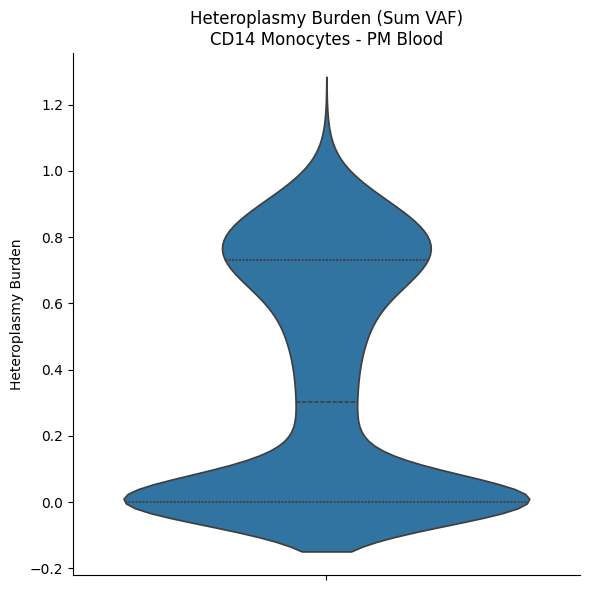

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cd14_mask = mgatk.obs['cell_type'] == 'CD14 Monos'
cd14_vaf_raw = mgatk.obsm['variant_vaf'][cd14_mask]
cd14_cov = mgatk.obsm['variant_coverage'][cd14_mask]

# Standard: true VAF = raw / coverage, then sum (burden)
true_vaf = np.divide(cd14_vaf_raw, cd14_cov + 1e-10, where=cd14_cov != 0)
heteroplasmy_burden = true_vaf.sum(axis=1)  # Sum VAF = standard burden

burden_pd = pd.Series(heteroplasmy_burden)
print("PM Standard burden stats:\n", burden_pd.describe())

plt.figure(figsize=(6, 6))
sns.violinplot(y=burden_pd, inner='quartile')
plt.title('Heteroplasmy Burden (Sum VAF)\nCD14 Monocytes - PM Blood')
plt.ylabel('Heteroplasmy Burden')
sns.despine()
plt.tight_layout()
plt.savefig('heteroplasmy_cd14_pm.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
Cell In[123], line 28
     22 burden_surg = compute_burden(mgatk, save_file='surg_cd14.npy')
     24 # PM (other notebook)
     25 # burden_pm = compute_burden(mgatk_pm, save_file='pm_cd14.npy')
     26 
     27 # Comparison
---> 28 burden_pm = np.load('pm_cd14.npy')
     29 n_match = min(len(burden_pm), len(burden_surg))
     30 df = pd.DataFrame({'PM': burden_pm[:n_match], 'Surgical': burden_surg[:n_match]})

File ~/miniconda3/envs/atac_env/lib/python3.9/site-packages/numpy/lib/npyio.py:427, in load(file, mmap_mode, allow_pickle, fix_imports, encoding, max_header_size)
    425     own_fid = False
    426 else:
--> 427     fid = stack.enter_context(open(os_fspath(file), "rb"))
    428     own_fid = True
    430 # Code to distinguish from NumPy binary files and pickles.

FileNotFoundError: [Errno 2] No such file or directory: 'pm_cd14.npy'


✅ PM saved: 2616 cells


In [56]:
np.save('/mnt/claw-raid/elliot/pm_heteroplasmy_counts.npy', counts)


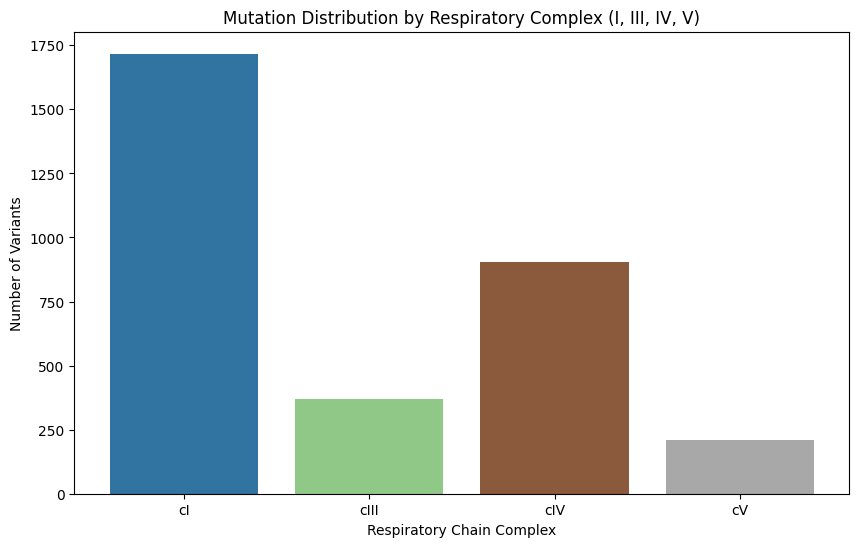

cI      1717
cIII     368
cIV      904
cV       211
Name: count, dtype: int64


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract positions from variant names
positions = [int(v.split('-')[1]) for v in mgatk.uns['variant_names']]

# Define complex ranges
def get_complex(pos):
    if 3307 <= pos <= 14673:  # ND genes
        if pos <= 4262 or 4470 <= pos <= 5511 or 10059 <= pos <= 10404 or 10760 <= pos <= 14673:
            return 'cI'
    if 14747 <= pos <= 15887:  # CYTB
        return 'cIII'
    if 5904 <= pos <= 9990:  # COX genes
        if pos <= 7445 or 7586 <= pos <= 8269 or 9207 <= pos <= 9990:
            return 'cIV'
    if 8366 <= pos <= 9207:  # ATP genes
        return 'cV'
    return 'other'

# Assign complexes
complexes = [get_complex(p) for p in positions]

# Count
counts = pd.Series(complexes).value_counts()
counts = counts[['cI', 'cIII', 'cIV', 'cV']]

# Plot
plt.figure(figsize=(10, 6))
colors = ['#3274A1', '#90C987', '#8B5A3C', '#A8A8A8']
plt.bar(range(len(counts)), counts.values, color=colors)
plt.xticks(range(len(counts)), counts.index)
plt.xlabel('Respiratory Chain Complex')
plt.ylabel('Number of Variants')
plt.title('Mutation Distribution by Respiratory Complex (I, III, IV, V)')
plt.show()

print(counts)

/tmp/ipykernel_1910451/2483840471.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')
/tmp/ipykernel_1910451/2483840471.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')


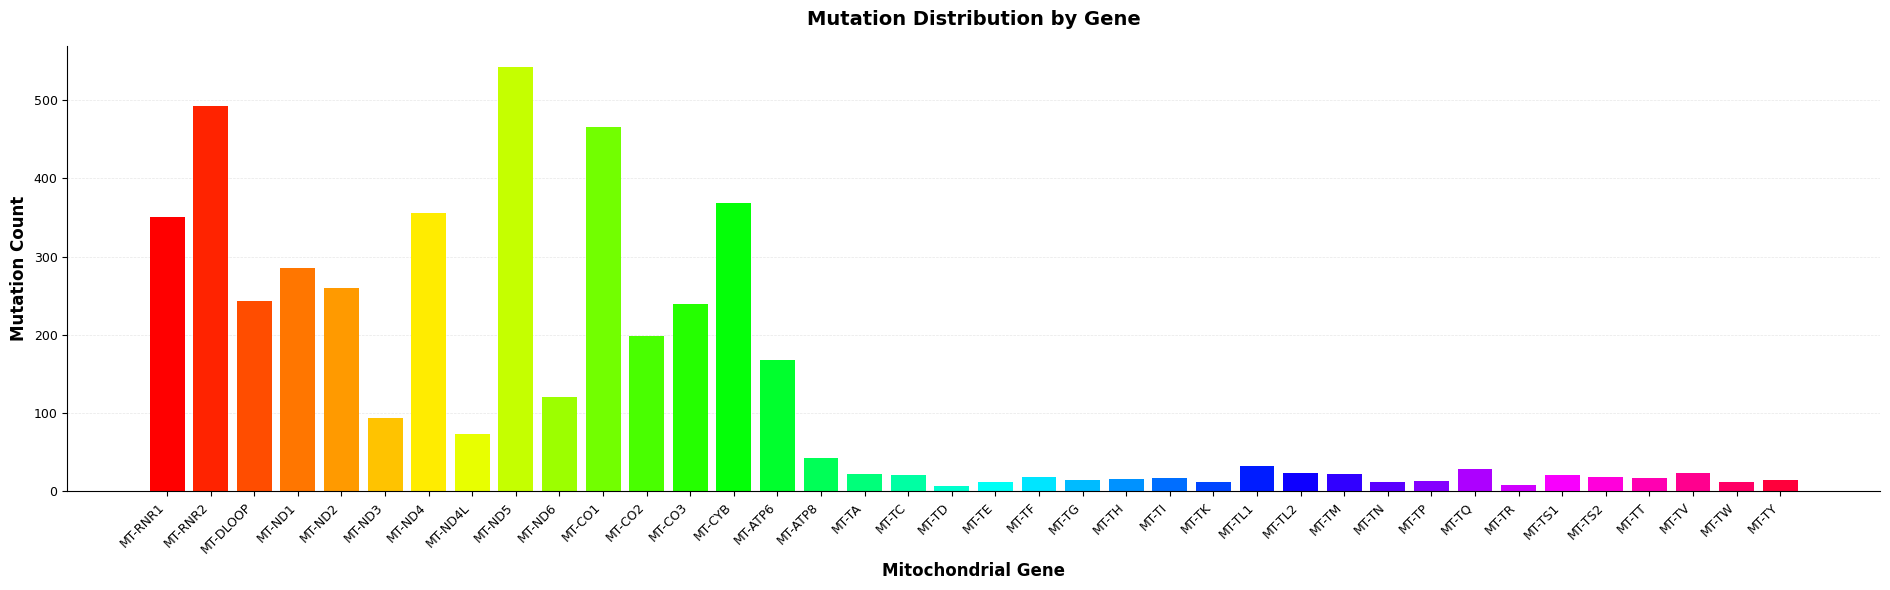


Total genes with variants: 38

Genes with counts:
MT-RNR1: 351
MT-RNR2: 492
MT-DLOOP: 243
MT-ND1: 285
MT-ND2: 260
MT-ND3: 94
MT-ND4: 356
MT-ND4L: 73
MT-ND5: 542
MT-ND6: 121
MT-CO1: 466
MT-CO2: 199
MT-CO3: 239
MT-CYB: 368
MT-ATP6: 168
MT-ATP8: 43
MT-TA: 22
MT-TC: 21
MT-TD: 7
MT-TE: 12
MT-TF: 19
MT-TG: 15
MT-TH: 16
MT-TI: 17
MT-TK: 12
MT-TL1: 33
MT-TL2: 24
MT-TM: 22
MT-TN: 12
MT-TP: 13
MT-TQ: 29
MT-TR: 8
MT-TS1: 21
MT-TS2: 19
MT-TT: 17
MT-TV: 23
MT-TW: 12
MT-TY: 14


In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Complete gene map with tRNAs
gene_map = {
    'MT-DLOOP': [(1, 576), (16024, 16569)],
    'MT-TF': [(577, 647)],
    'MT-RNR1': [(648, 1601)],
    'MT-TV': [(1602, 1670)],
    'MT-RNR2': [(1671, 3229)],
    'MT-TL1': [(3230, 3304)],
    'MT-ND1': [(3307, 4262)],
    'MT-TI': [(4263, 4331)],
    'MT-TQ': [(4329, 4400)],
    'MT-TM': [(4402, 4469)],
    'MT-ND2': [(4470, 5511)],
    'MT-TW': [(5512, 5579)],
    'MT-TA': [(5587, 5655)],
    'MT-TN': [(5657, 5729)],
    'MT-TC': [(5761, 5826)],
    'MT-TY': [(5826, 5891)],
    'MT-CO1': [(5904, 7445)],
    'MT-TS1': [(7446, 7514)],
    'MT-TD': [(7518, 7585)],
    'MT-CO2': [(7586, 8269)],
    'MT-TK': [(8295, 8364)],
    'MT-ATP8': [(8366, 8572)],
    'MT-ATP6': [(8527, 9207)],
    'MT-CO3': [(9207, 9990)],
    'MT-TG': [(9991, 10058)],
    'MT-ND3': [(10059, 10404)],
    'MT-TR': [(10405, 10469)],
    'MT-ND4L': [(10470, 10766)],
    'MT-ND4': [(10760, 12137)],
    'MT-TH': [(12138, 12206)],
    'MT-TS2': [(12207, 12265)],
    'MT-TL2': [(12266, 12336)],
    'MT-ND5': [(12337, 14148)],
    'MT-ND6': [(14149, 14673)],
    'MT-TE': [(14674, 14742)],
    'MT-CYB': [(14747, 15887)],
    'MT-TT': [(15888, 15953)],
    'MT-TP': [(15956, 16023)],
}

# Get positions and assign genes
positions = [int(v.split('-')[1]) for v in mgatk.uns['variant_names']]

def assign_gene(pos):
    for gene, ranges in gene_map.items():
        for start, end in ranges:
            if start <= pos <= end:
                return gene
    return 'Other'

genes = [assign_gene(p) for p in positions]

# Generate nice colors
def generate_colors(n):
    cmap = plt.cm.get_cmap('tab20')
    if n > 20:
        cmap = plt.cm.get_cmap('hsv')
    return [cmap(i/n) for i in range(n)]

# Define gene order
gene_order = [
    'MT-RNR1', 'MT-RNR2', 'MT-DLOOP',
    'MT-ND1', 'MT-ND2', 'MT-ND3', 'MT-ND4', 'MT-ND4L', 'MT-ND5', 'MT-ND6',
    'MT-CO1', 'MT-CO2', 'MT-CO3',
    'MT-CYB',
    'MT-ATP6', 'MT-ATP8',
    'MT-TA', 'MT-TC', 'MT-TD', 'MT-TE', 'MT-TF', 'MT-TG', 'MT-TH', 'MT-TI',
    'MT-TK', 'MT-TL1', 'MT-TL2', 'MT-TM', 'MT-TN', 'MT-TP', 'MT-TQ', 'MT-TR',
    'MT-TS1', 'MT-TS2', 'MT-TT', 'MT-TV', 'MT-TW', 'MT-TY'
]

# Count variants per gene
gene_counts_dict = pd.Series(genes).value_counts().to_dict()

# Create ordered counts
gene_counts_ordered = []
genes_present = []

for gene in gene_order:
    if gene in gene_counts_dict and gene_counts_dict[gene] > 0:
        genes_present.append(gene)
        gene_counts_ordered.append(gene_counts_dict[gene])

# Create the plot
fig, ax = plt.subplots(figsize=(max(16, len(genes_present) * 0.5), 6))

# Get colors - one per gene
colors = generate_colors(len(genes_present))

# Create bar plot
ax.bar(range(len(genes_present)), gene_counts_ordered, width=0.8, color=colors, edgecolor='none')

# Set x-axis labels
ax.set_xticks(range(len(genes_present)))
ax.set_xticklabels(genes_present, rotation=45, ha='right', fontsize=9)

# Styling
ax.set_title('Mutation Distribution by Gene', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mitochondrial Gene', fontsize=12, fontweight='bold')
ax.set_ylabel('Mutation Count', fontsize=12, fontweight='bold')

plt.yticks(fontsize=9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light grid on y-axis only
ax.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal genes with variants: {len(genes_present)}")
print(f"\nGenes with counts:")
for gene, count in zip(genes_present, gene_counts_ordered):
    print(f"{gene}: {count}")

Plotting first 5 confident variants out of 4710 total confident variants
Processing variant 1: Index 0, Name: A-10172-G


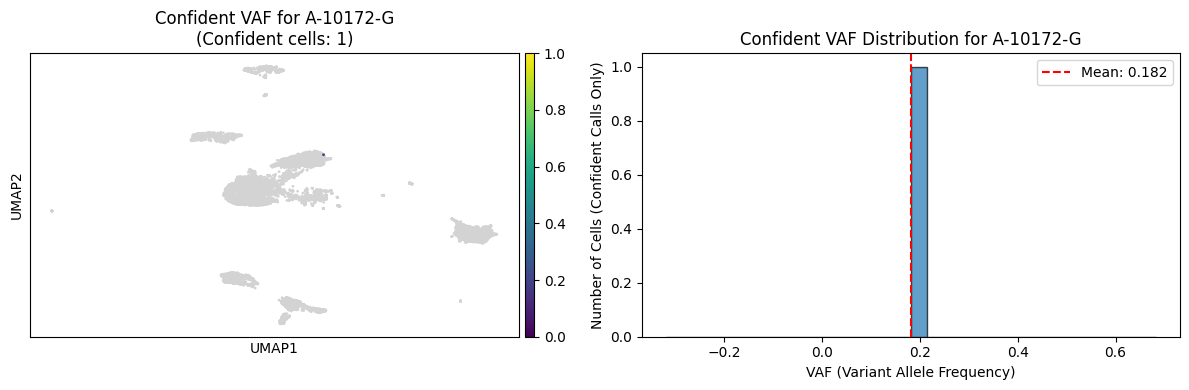

Variant A-10172-G (Index 0):
  Confident cells detected: 1
  Mean coverage: 24.7
  Total cells: 7628
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.182
  Confident VAF range: 0.182 - 0.182
---
Processing variant 2: Index 1, Name: A-10726-G


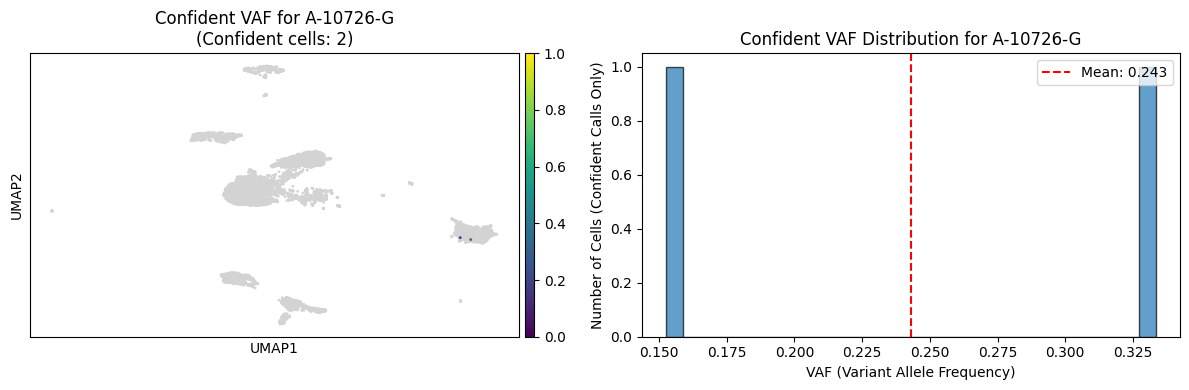

Variant A-10726-G (Index 1):
  Confident cells detected: 2
  Mean coverage: 20.0
  Total cells: 7628
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 2
  Mean confident VAF: 0.243
  Confident VAF range: 0.153 - 0.333
---
Processing variant 3: Index 2, Name: A-11163-G


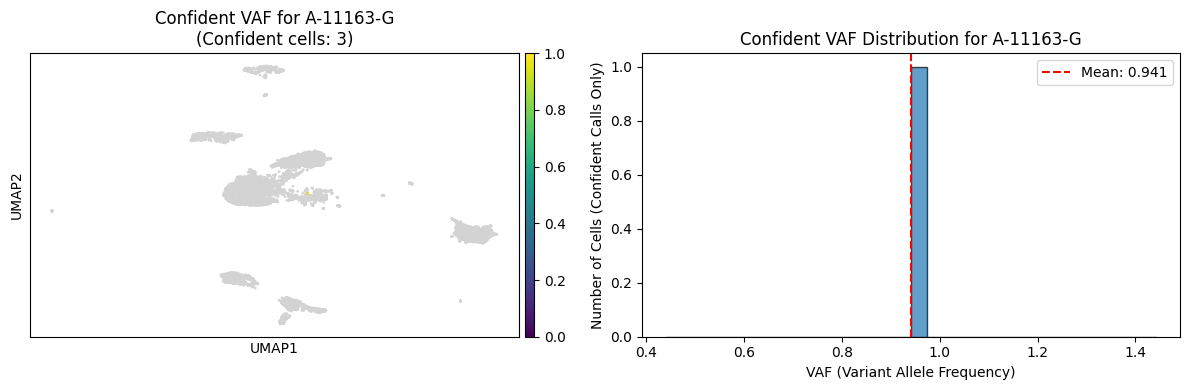

Variant A-11163-G (Index 2):
  Confident cells detected: 3
  Mean coverage: 30.0
  Total cells: 7628
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.941
  Confident VAF range: 0.941 - 0.941
---
Processing variant 4: Index 3, Name: A-11225-G
No confident non-zero calls for variant A-11225-G
Processing variant 5: Index 4, Name: A-11382-C


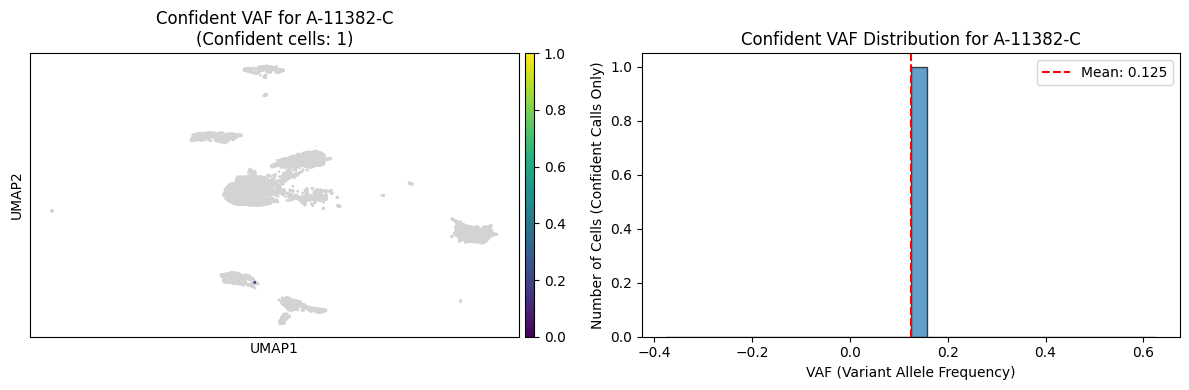

Variant A-11382-C (Index 4):
  Confident cells detected: 1
  Mean coverage: 15.6
  Total cells: 7628
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.125
  Confident VAF range: 0.125 - 0.125
---


In [11]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:5]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values > 0)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

Found 40 enriched variants
     idx       name  in_target  in_other  enrichment
4    324   A-8989-G          3         0         3.0
28  2530  A-13096-G          3         0         3.0
2    137   C-3590-T          2         0         2.0
0      1  A-10726-G          2         0         2.0
3    206   G-5418-T          2         0         2.0
5    399   C-2778-T          2         0         2.0
6    608   C-2680-t          2         0         2.0
1     22   A-1476-G          2         0         2.0
7    685  T-11860-C          4         1         2.0
8    898   C-7069-T          2         0         2.0
10  1166    C-779-T          2         0         2.0
9   1144   C-5302-T          2         0         2.0
12  1245   T-7996-C          2         0         2.0
13  1301   A-4632-G          2         0         2.0
14  1392  C-15629-T          2         0         2.0
11  1189   C-9963-T          2         0         2.0
16  1594   A-8557-G          2         0         2.0
18  1700   C-3329-T

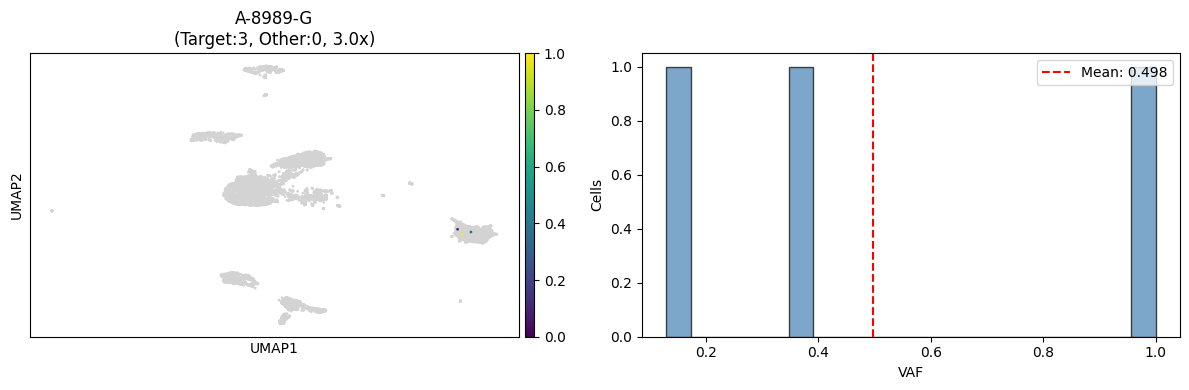

In [44]:
# Find cluster-enriched variants
TARGET_CLUSTERS = ['0']
MIN_CELLS_IN_TARGET = 2
MAX_CELLS_IN_OTHER = 3
MIN_ENRICHMENT = 1.5

import numpy as np
import pandas as pd

_mask = np.isin(mgatk.obs['leiden'].values, TARGET_CLUSTERS)
_enriched = []

for _i in range(len(mgatk.uns['variant_names'])):
    _vaf = mgatk.obsm['variant_vaf'][:, _i]
    _conf = mgatk.obsm['variant_confident'][:, _i]
    _in_target = (_conf & _mask & (_vaf > 0)).sum()
    _in_other = (_conf & ~_mask & (_vaf > 0)).sum()
    _enrich = _in_target / (_in_other + 1)
    
    if _in_target >= MIN_CELLS_IN_TARGET and _in_other <= MAX_CELLS_IN_OTHER and _enrich >= MIN_ENRICHMENT:
        _enriched.append({'idx': _i, 'name': mgatk.uns['variant_names'][_i], 
                         'in_target': _in_target, 'in_other': _in_other, 'enrichment': _enrich})

enriched_df = pd.DataFrame(_enriched).sort_values('enrichment', ascending=False)
print(f"Found {len(enriched_df)} enriched variants")
print(enriched_df)

VARIANT_TO_PLOT = 0

import matplotlib.pyplot as plt
import scanpy as sc

_r = enriched_df.iloc[VARIANT_TO_PLOT]
_m = mgatk.obsm['variant_confident'][:, _r['idx']] & np.isin(mgatk.obs['leiden'].values, TARGET_CLUSTERS) & (mgatk.obsm['variant_vaf'][:, _r['idx']] > 0)
mgatk.obs['_tmp'] = np.where(_m, mgatk.obsm['variant_vaf'][:, _r['idx']], np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sc.pl.umap(mgatk, color='_tmp', cmap="viridis", vmin=0, vmax=1,
           title=f"{_r['name']}\n(Target:{int(_r['in_target'])}, Other:{int(_r['in_other'])}, {_r['enrichment']:.1f}x)",
           ax=ax1, show=False, na_color='lightgray')
ax2.hist(mgatk.obs.loc[_m, '_tmp'].dropna(), bins=20, alpha=0.7, edgecolor='black', color='steelblue')
ax2.set_xlabel('VAF')
ax2.set_ylabel('Cells')
ax2.axvline(mgatk.obs.loc[_m, '_tmp'].mean(), color='red', linestyle='--', label=f'Mean: {mgatk.obs.loc[_m, "_tmp"].mean():.3f}')
ax2.legend()
plt.tight_layout()
plt.show()
mgatk.obs.drop(columns=['_tmp'], inplace=True)

Variant A-10172-G: Insufficient data points (1)
Variant A-10726-G: Insufficient data points (2)
Variant A-11163-G: Insufficient data points (1)
Variant A-11225-G: Insufficient data points (0)
Variant A-11382-C: Insufficient data points (1)
Variant A-11415-C: Insufficient data points (1)


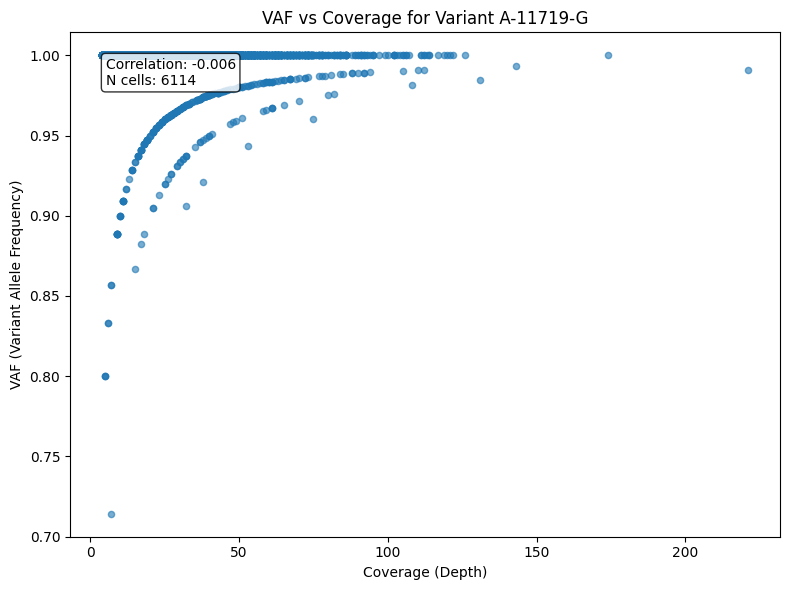

Variant A-11719-G:
  Coverage range: 4.0 - 221.0
  Mean coverage: 25.3
  VAF range: 0.714 - 1.000
  Correlation (VAF vs Coverage): -0.006
---


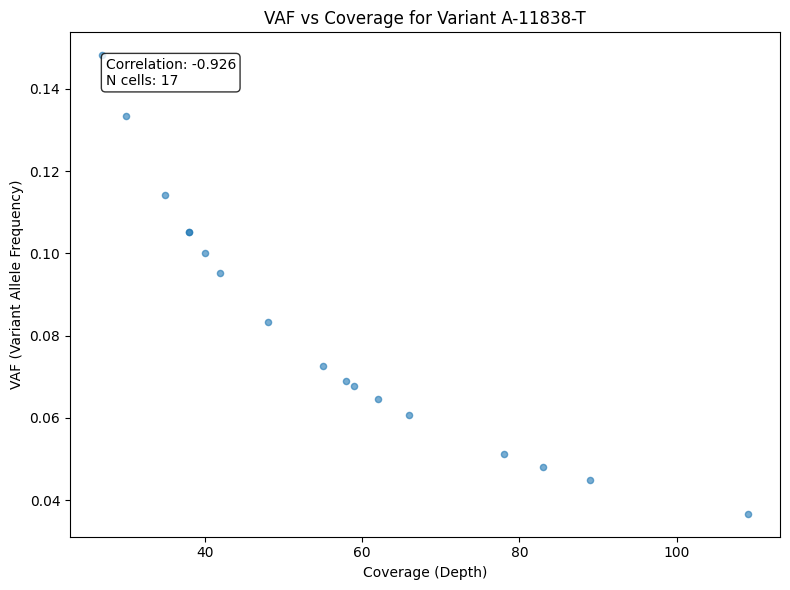

Variant A-11838-T:
  Coverage range: 27.0 - 109.0
  Mean coverage: 56.3
  VAF range: 0.037 - 0.148
  Correlation (VAF vs Coverage): -0.926
---
Variant A-11858-C: Insufficient data points (1)
Variant A-1204-C: Insufficient data points (1)
Variant A-12412-C: Insufficient data points (1)


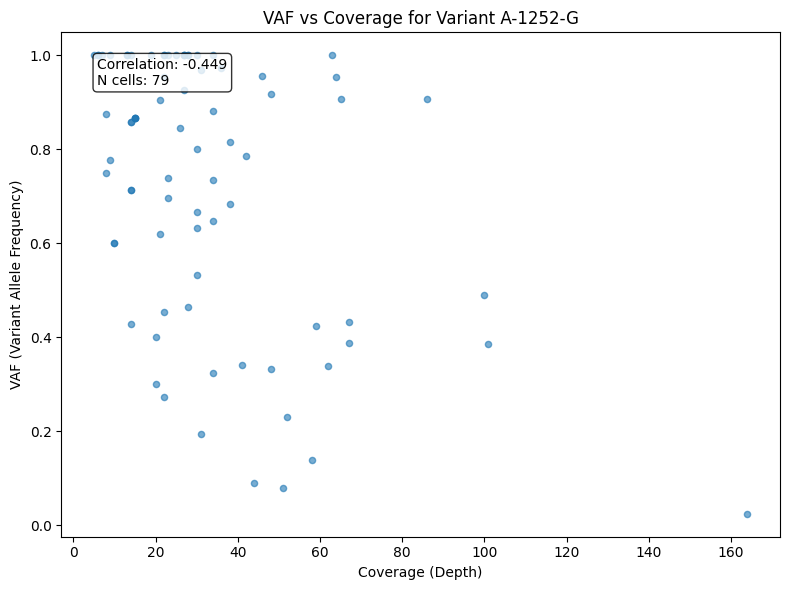

Variant A-1252-G:
  Coverage range: 5.0 - 164.0
  Mean coverage: 32.8
  VAF range: 0.024 - 1.000
  Correlation (VAF vs Coverage): -0.449
---
Variant A-12583-G: Insufficient data points (2)
Variant A-12861-C: Insufficient data points (1)
Variant A-13043-C: Insufficient data points (1)
Variant A-13094-T: Insufficient data points (0)
Variant A-13329-C: Insufficient data points (1)
Variant A-13558-G: Insufficient data points (1)
Variant A-13694-C: Insufficient data points (1)
Variant A-13730-G: Insufficient data points (1)
Variant A-13879-T: Insufficient data points (1)
Variant A-14721-G: Insufficient data points (1)
Variant A-1476-G: Insufficient data points (2)
Variant A-14991-T: Insufficient data points (0)
Variant A-15093-G: Insufficient data points (3)
Variant A-15170-G: Insufficient data points (0)
Variant A-15301-G: Insufficient data points (3)
Variant A-15708-G: Insufficient data points (4)


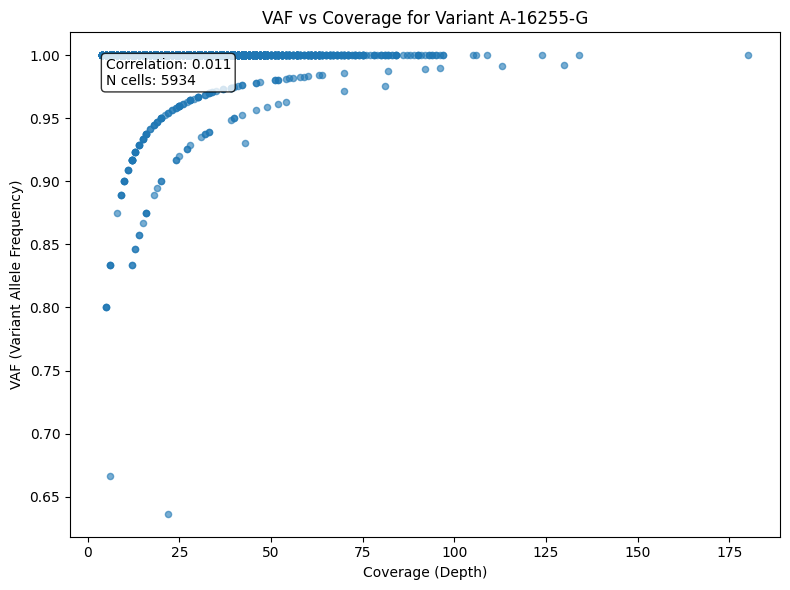

Variant A-16255-G:
  Coverage range: 4.0 - 180.0
  Mean coverage: 20.7
  VAF range: 0.636 - 1.000
  Correlation (VAF vs Coverage): 0.011
---


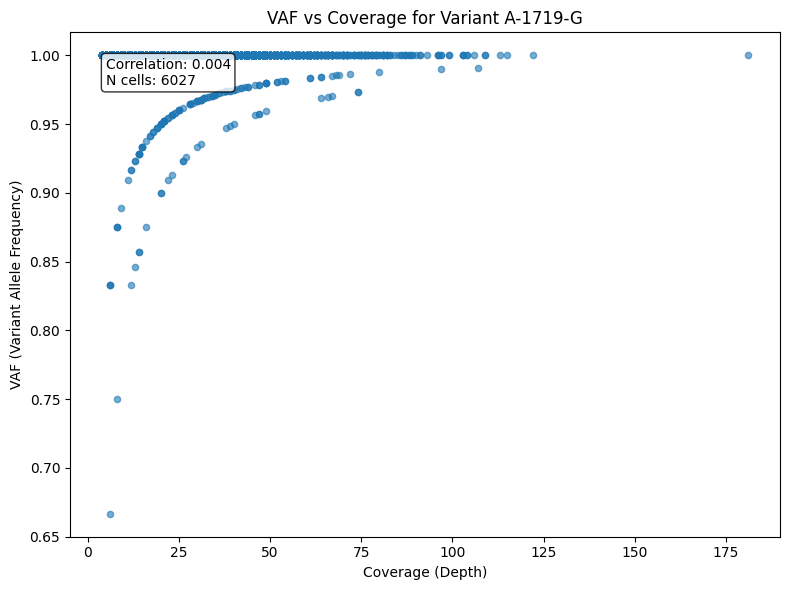

Variant A-1719-G:
  Coverage range: 4.0 - 181.0
  Mean coverage: 23.1
  VAF range: 0.667 - 1.000
  Correlation (VAF vs Coverage): 0.004
---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:30]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0) & (coverage_values > 0)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")

In [ ]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()
variant_names_list = []
# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.5) &  # Variant-level criterion
        (mean_coverage >= 20) &        # Variant-level criterion
        (cell_vaf >= 0.1)        # Cell-level: VAF > 10%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")
print("variants left" , variants_with_expression_after)
# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (7626, 4710)
Non-zero VAF values before filtering: 169464
Variants with at least one expressing cell before filtering: 4113
Non-zero VAF values after high-quality filtering: 71866
Percentage of calls retained: 42.4%
Variants with at least one expressing cell after filtering: 2363
Percentage of variants retained: 57.5%
Variants completely eliminated by filtering: 1750
variants left 2363

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']


In [ ]:
# Boolean mask: True for variants with at least one retained (non-zero) cell
high_quality_mask = (high_quality_vaf_matrix > 0).any(axis=0)

# Get corresponding variant names
high_quality_variant_names = np.array(variant_names)[high_quality_mask]
print(high_quality_variant_names)
print(len(high_quality_variant_names))

## Flip variants to match format 
converted = [f"MT-{alt}-{pos}-{ref}" for ref, pos, alt in (v.split('-') for v in high_quality_variant_names)]
print(converted)

required_columns = ["chr", "pos", "ref", "alt"]

genebe_df = pd.DataFrame(
    [v.split('-') for v in converted],
    columns=["chr","ref", "pos", "alt"]
)
genebe_df = genebe_df[required_columns]

print(genebe_df.head())

['A-10172-G' 'A-11163-G' 'A-11719-G' ... 'G-8784-A' 'G-8860-A' 'G-982-A']
2363
['MT-G-10172-A', 'MT-G-11163-A', 'MT-G-11719-A', 'MT-T-11838-A', 'MT-C-12412-A', 'MT-G-1252-A', 'MT-G-12583-A', 'MT-C-12861-A', 'MT-G-13558-A', 'MT-G-13730-A', 'MT-G-1476-A', 'MT-G-15093-A', 'MT-G-15301-A', 'MT-G-15708-A', 'MT-G-1719-A', 'MT-G-1949-A', 'MT-G-2174-A', 'MT-G-2553-A', 'MT-G-3688-A', 'MT-G-3850-A', 'MT-c-4393-A', 'MT-G-4482-A', 'MT-G-4830-A', 'MT-G-4849-A', 'MT-G-5245-A', 'MT-G-529-A', 'MT-G-5590-A', 'MT-G-6069-A', 'MT-G-6999-A', 'MT-G-7239-A', 'MT-G-769-A', 'MT-G-8007-A', 'MT-G-8189-A', 'MT-G-874-A', 'MT-G-9267-A', 'MT-G-9554-A', 'MT-G-9906-A', 'MT-G-10172-C', 'MT-T-11147-C', 'MT-T-11759-C', 'MT-T-11784-C', 'MT-T-12448-C', 'MT-T-12755-C', 'MT-T-12851-C', 'MT-T-13698-C', 'MT-T-13781-C', 'MT-T-13946-C', 'MT-T-1413-C', 'MT-T-14345-C', 'MT-T-14395-C', 'MT-T-14819-C', 'MT-T-14826-C', 'MT-T-14912-C', 'MT-T-14956-C', 'MT-G-15301-C', 'MT-T-15394-C', 'MT-T-15519-C', 'MT-T-15755-C', 'MT-T-15774-C', 'MT-T

In [ ]:
import genebe as gnb
annotated_PBMC = gnb.annotate_dataframe_variants(genebe_df,use_ensembl=True,use_refseq=False, genome='hg38', flatten_consequences=False)

2025-10-21 16:06:46 - WARNING - You are not logged in to GeneBe. We recommend using username and api_key arguments. Find out more on https://genebe.net/api .


Error: .netrc file not found.


100%|██████████| 24/24 [00:11<00:00,  2.17it/s]


In [ ]:
annotated_PBMC.to_csv('PBMC_PostMortem_genebe.csv', index=False)

In [ ]:
#Gene classification 
gene_classification = {
    'MT-ND1': 'Complex I',
    'MT-ND2': 'Complex I',
    'MT-ND3': 'Complex I',
    'MT-ND4': 'Complex I',
    'MT-ND4L': 'Complex I',
    'MT-ND5': 'Complex I',
    'MT-ND6': 'Complex I',
    'MT-CO1': 'Complex IV',
    'MT-CO2': 'Complex IV',
    'MT-CO3': 'Complex IV',
    'MT-CYB': 'Complex III',
    'MT-ATP6': 'Complex V',
    'MT-ATP8': 'Complex V',
    'MT-RNR1': 'rRNA',
    'MT-RNR2': 'rRNA',
    'MT-TF': 'tRNA',  
    'MT-TV': 'tRNA',
    'MT-TI': 'tRNA',
    'MT-TL1': 'tRNA',
    'MT-TL2': 'tRNA',
    'MT-TK': 'tRNA',
    'MT-TM': 'tRNA',
    'MT-TP': 'tRNA',
    'MT-TS1': 'tRNA',
    'MT-TS2': 'tRNA',
    'MT-TW': 'tRNA',
    'MT-TA': 'tRNA',
    'MT-TC': 'tRNA',
    'MT-TY': 'tRNA',
    'MT-TH': 'tRNA',
    'MT-TG': 'tRNA',
    'MT-TR': 'tRNA',
    'MT-TN': 'tRNA',
    'MT-TD': 'tRNA',
    'MT-TE': 'tRNA',
    'MT-TQ': 'tRNA'
}

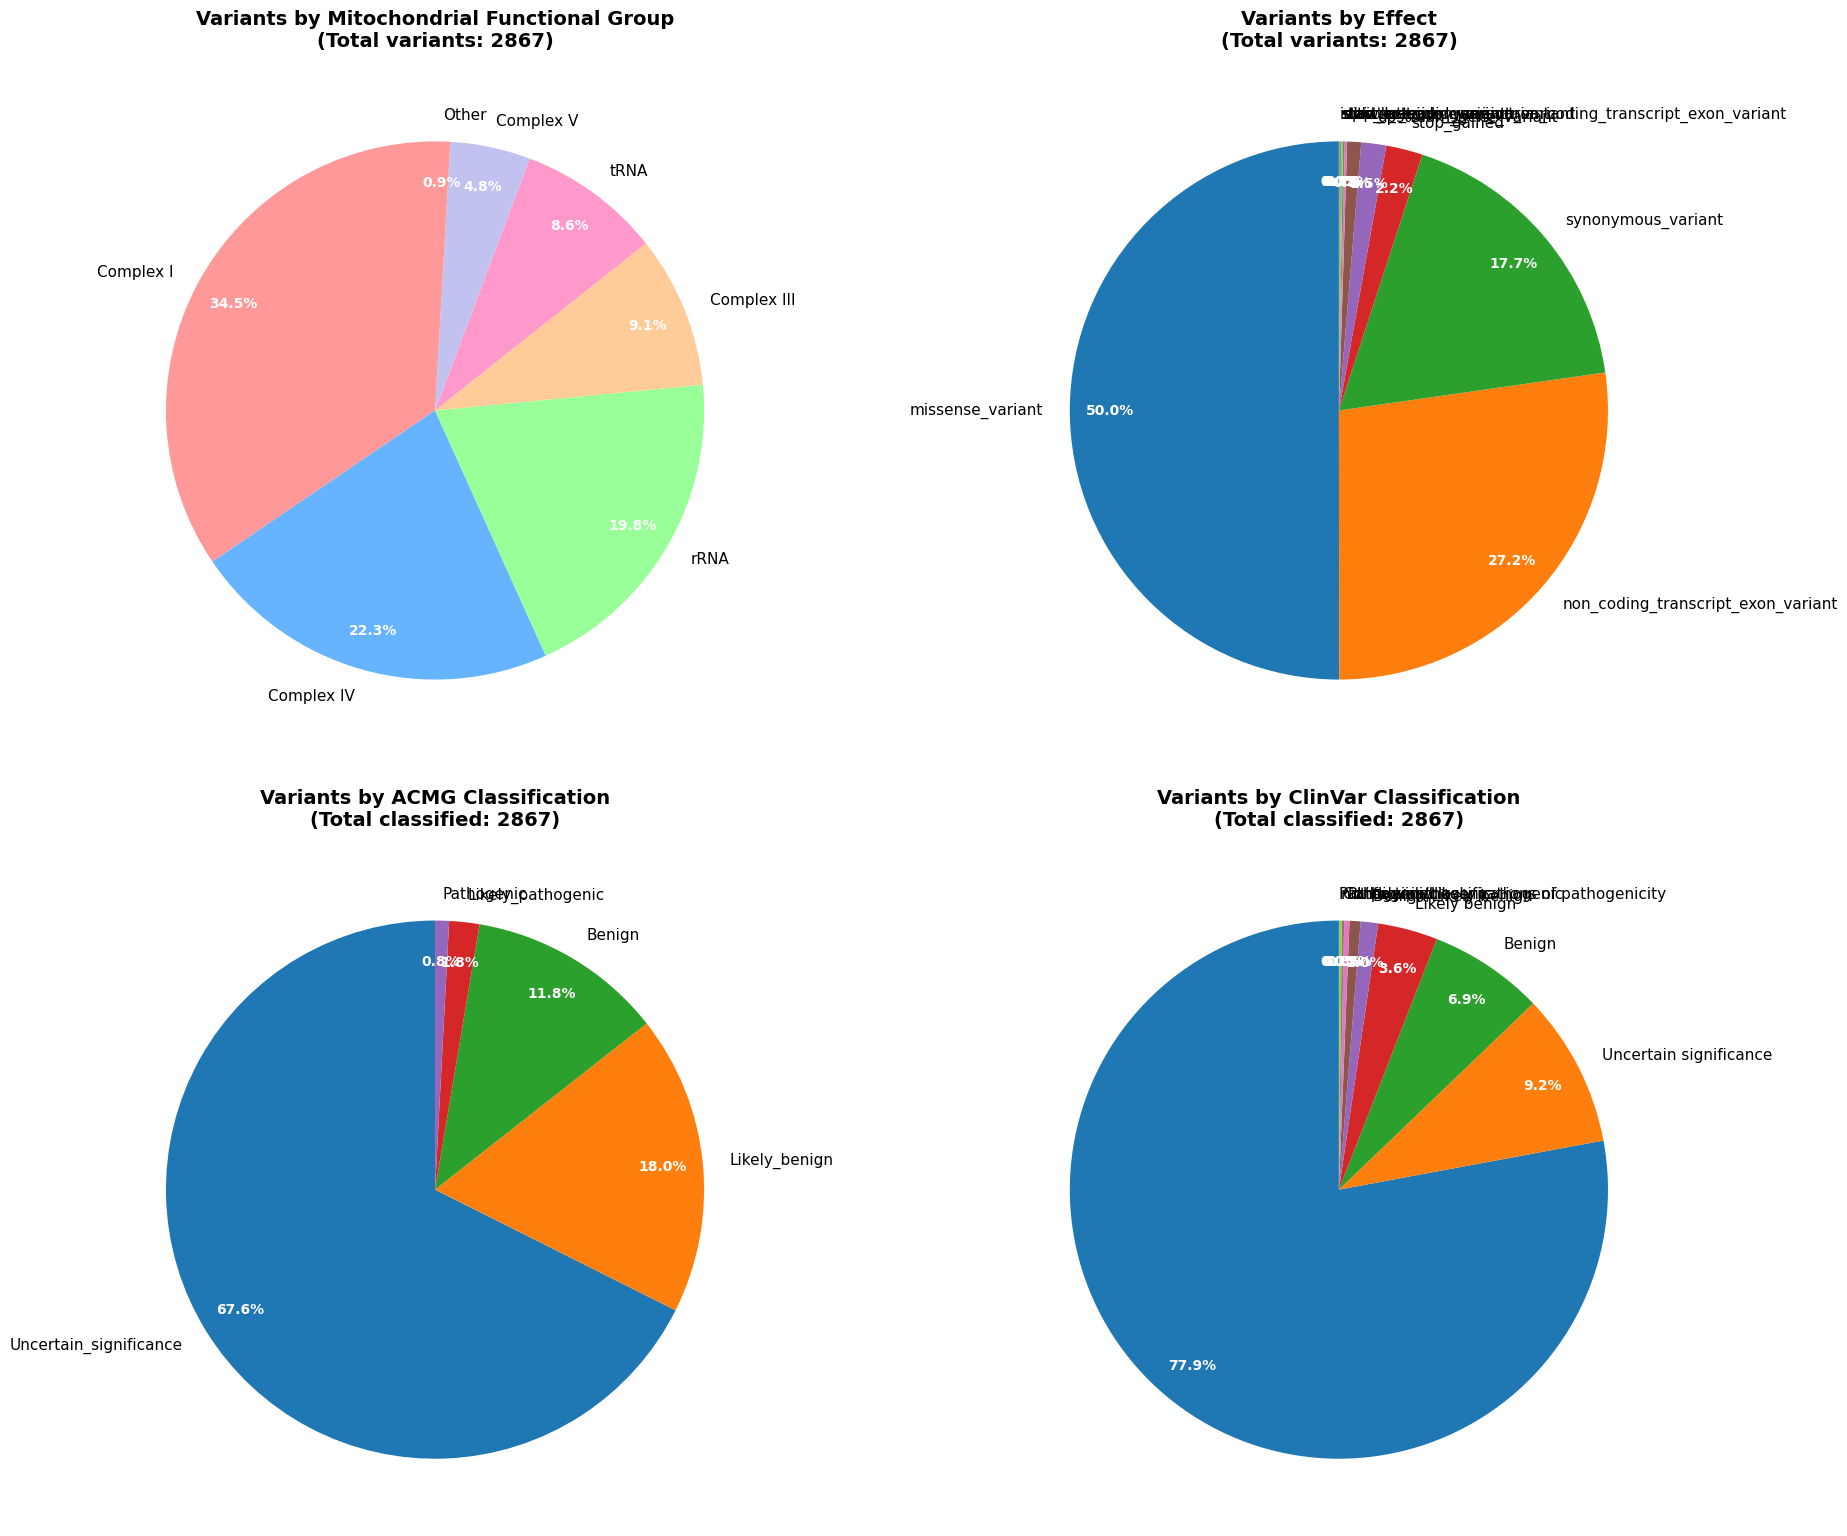

=== SUMMARY STATISTICS ===

1. Mitochondrial Functional Group Distribution:
   Total functional groups represented: 7
   Most common functional group: Complex I (989 variants)
   All functional groups:
      Complex I: 989 variants (34.5%)
      Complex IV: 638 variants (22.3%)
      rRNA: 567 variants (19.8%)
      Complex III: 262 variants (9.1%)
      tRNA: 247 variants (8.6%)
      Complex V: 138 variants (4.8%)
      Other: 26 variants (0.9%)

2. Individual Gene Symbol Distribution:
   Total genes represented: 32
   Most common gene: MT-ND5 (339 variants)
   Top 10 genes:
      1. MT-ND5 (Complex I): 339 variants (11.8%)
      2. MT-CO1 (Complex IV): 327 variants (11.4%)
      3. MT-RNR2 (rRNA): 314 variants (11.0%)
      4. MT-CYB (Complex III): 262 variants (9.1%)
      5. MT-RNR1 (rRNA): 253 variants (8.8%)
      6. MT-ND4 (Complex I): 209 variants (7.3%)
      7. MT-ND1 (Complex I): 183 variants (6.4%)
      8. MT-CO3 (Complex IV): 162 variants (5.7%)
      9. MT-CO2 (Complex 

In [ ]:
# Create a copy of the dataframe and add the functional classification
annotated_PBMC_classified = annotated_PBMC.copy()
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_symbol'].map(gene_classification)

# Handle any genes not in the classification (mark as 'Other')
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_functional_group'].fillna('Other')

# Create a 2x2 subplot layout for the pie charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Increased figure size

# Function to prepare data for pie chart (handle NaN values and limit categories)
def prepare_pie_data(series, max_categories=20):
    # Count values, excluding NaN
    value_counts = series.value_counts(dropna=True)
    
    # If there are more categories than max_categories, group the smallest ones as "Other"
    if len(value_counts) > max_categories:
        top_categories = value_counts.head(max_categories - 1)
        other_count = value_counts.iloc[max_categories - 1:].sum()
        
        # Create new series with "Other" category
        pie_data = top_categories.copy()
        pie_data['Other'] = other_count
    else:
        pie_data = value_counts
    
    return pie_data

# 1. Gene Functional Group pie chart (using your classification)
gene_functional_data = prepare_pie_data(annotated_PBMC_classified['gene_functional_group'])
colors1 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']  # Custom colors for complexes

# Option 1: Use pctdistance and labeldistance to control spacing
wedges1, texts1, autotexts1 = ax1.pie(gene_functional_data.values, labels=gene_functional_data.index, 
                                       autopct='%1.1f%%', startangle=90, 
                                       colors=colors1[:len(gene_functional_data)],
                                       pctdistance=0.85,    # Distance of percentage labels from center
                                       labeldistance=1.1)   # Distance of category labels from center

# Adjust text properties to prevent overlap
for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts1:
    text.set_fontsize(11)

ax1.set_title(f'Variants by Mitochondrial Functional Group\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 2. Effect pie chart with adjusted spacing
effect_data = prepare_pie_data(annotated_PBMC['effect'])
wedges2, texts2, autotexts2 = ax2.pie(effect_data.values, labels=effect_data.index, 
                                       autopct='%1.1f%%', startangle=90,
                                       pctdistance=0.85, labeldistance=1.1)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts2:
    text.set_fontsize(11)

ax2.set_title(f'Variants by Effect\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 3. ACMG Classification pie chart
acmg_data = prepare_pie_data(annotated_PBMC['acmg_classification'])
if len(acmg_data) > 0:
    wedges3, texts3, autotexts3 = ax3.pie(acmg_data.values, labels=acmg_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts3:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts3:
        text.set_fontsize(11)
    
    ax3.set_title(f'Variants by ACMG Classification\n(Total classified: {acmg_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax3.text(0.5, 0.5, 'No ACMG Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax3.set_title('ACMG Classification', fontsize=14, fontweight='bold', pad=20)

# 4. ClinVar Classification pie chart
clinvar_data = prepare_pie_data(annotated_PBMC['clinvar_classification'])
if len(clinvar_data) > 0:
    wedges4, texts4, autotexts4 = ax4.pie(clinvar_data.values, labels=clinvar_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts4:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts4:
        text.set_fontsize(11)
    
    ax4.set_title(f'Variants by ClinVar Classification\n(Total classified: {clinvar_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No ClinVar Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax4.set_title('ClinVar Classification', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Print summary statistics for each category
print("=== SUMMARY STATISTICS ===")
print(f"\n1. Mitochondrial Functional Group Distribution:")
functional_summary = annotated_PBMC_classified['gene_functional_group'].value_counts(dropna=True)
print(f"   Total functional groups represented: {len(functional_summary)}")
print(f"   Most common functional group: {functional_summary.index[0]} ({functional_summary.iloc[0]} variants)")
print(f"   All functional groups:")
for group, count in functional_summary.items():
    print(f"      {group}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n2. Individual Gene Symbol Distribution:")
gene_summary = annotated_PBMC['gene_symbol'].value_counts(dropna=True)
print(f"   Total genes represented: {len(gene_summary)}")
print(f"   Most common gene: {gene_summary.index[0]} ({gene_summary.iloc[0]} variants)")
print(f"   Top 10 genes:")
for i, (gene, count) in enumerate(gene_summary.head(10).items()):
    functional_group = gene_classification.get(gene, 'Other')
    print(f"      {i+1}. {gene} ({functional_group}): {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n3. Effect Distribution:")
effect_summary = annotated_PBMC['effect'].value_counts(dropna=True)
print(f"   Total effect types: {len(effect_summary)}")
if len(effect_summary) > 0:
    print(f"   Most common effect: {effect_summary.index[0]} ({effect_summary.iloc[0]} variants)")
    print(f"   All effects:")
    for effect, count in effect_summary.items():
        print(f"      {effect}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

acmg_summary = annotated_PBMC['acmg_classification'].value_counts(dropna=True)
print(f"\n4. ACMG Classification Distribution:")
print(f"   Total ACMG classified variants: {annotated_PBMC['acmg_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['acmg_classification'].isna().sum()}")
for classification, count in acmg_summary.items():
    print(f"      {classification}: {count} variants")

print(f"\n5. ClinVar Classification Distribution:")
clinvar_summary = annotated_PBMC['clinvar_classification'].value_counts(dropna=True)
print(f"   Total ClinVar classified variants: {annotated_PBMC['clinvar_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['clinvar_classification'].isna().sum()}")
if len(clinvar_summary) > 0:
    for classification, count in clinvar_summary.items():
        print(f"      {classification}: {count} variants")

In [ ]:
## Import mitoTIP dataframe to look at tRNA variants only 
mitoTIP = pd.read_csv('/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Usefull_Stuff/mitotip_scores.txt', sep='\t')
mitoTIP.head(20)

,Position,rCRS,Alt,MitoTIP_Score,Quartile,Count,Percentage,Mitomap_Status
0,577,G,:,20.3833,Q1,0,0.0,Absent
1,577,G,A,17.7500,Q1,0,0.0,Absent
2,577,G,C,17.7500,Q1,0,0.0,Absent
3,577,G,T,17.7500,Q1,0,0.0,Absent
4,578,T,:,18.6851,Q1,0,0.0,Absent
5,578,T,A,18.6851,Q1,0,0.0,Absent
6,578,T,C,16.6004,Q1,0,0.0,Absent
7,578,T,G,18.6851,Q1,0,0.0,Absent
8,579,T,:,17.6526,Q1,0,0.0,Absent
9,579,T,A,17.6526,Q1,0,0.0,Absent


In [ ]:
## Dataframe containing tRNA variants likely or poissbly pathogenic as per mitoTIP scoring method 
mitoTIP_filtered = mitoTIP[(mitoTIP['Quartile'] == 'Q2') | (mitoTIP['Quartile'] == 'Q1')]
mitoTIP_filtered.head(20)

Empty DataFrame
Columns: [Position, rCRS, Alt, MitoTIP_Score, Quartile, Count, Percentage, Mitomap_Status]
Index: []
